In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import anndata as ad
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

In [2]:
import seaborn as sns
from sklearn.metrics import auc

In [3]:
import mellon

In [4]:
from sklearn.metrics import precision_recall_curve, average_precision_score

### Note about reading files:
#### Replace the path with where the results of packages save. No need to copy the full path, just before the name of dataset folder.

In [74]:
def get_benchmarking_results(enr,pop,seed,batch_sd,package,ds):
    #jobid = ds+"-"+pop+"-"+enr+"-"+seed+"-"+batch_sd+"-No-mellon_pca-fractal-No-Yes-No"
    jobid2 = ds+"-"+pop+"-"+enr+"-"+seed+"-"+batch_sd+"-No-mellon_pca-fractal-No-Yes-No"
    #path = '/fh/fast/setty_m/user/ryang/differential_abundance/benchmarkDA/benchmark_python/synthetic/'+ds+"/"+jobid+"/iteration_0"+'/'
    path2 = '/fh/fast/setty_m/user/ryang/differential_abundance/benchmarkDA/benchmark_synthetic_0227_pca/synthetic/'+ds+"/"+jobid2+"/iteration_0"+'/'
    index_col = np.array(pd.read_csv(path2+'benchmark_'+ds+"_pop_"+pop+'_enr'+enr+"_seed"+seed+"_batchEffect"+batch_sd+"_package_performance.DAresults."+"mellon"+".csv",index_col = 0).index)
    if package in[ "daseq" , "milo" , "cydar" , "louvain" ]:
        package_performance = pd.read_csv(path+'benchmark_'+ds+"_pop_"+pop+'_enr'+enr+"_seed"+seed+"_batchEffect"+batch_sd+"_package_performance.DAresults."+package+".csv")
        package_performance.index = index_col
    # if package in ["mellon_high_ls","meld","cna","meld_default","mellon"]:
    #     batch_sd_processed = str(int(float(batch_sd)))
    #     package_performance = pd.read_csv(path2+'benchmark_'+ds+"_pop_"+pop+'_enr'+enr+"_seed"+seed+"_batchEffect"+batch_sd+"_package_performance.DAresults."+package+".csv",index_col = 0)
    if package in ["meld","cna","meld_default"]:
        batch_sd_processed = str(int(float(batch_sd)))
        package_performance = pd.read_csv(path2+'benchmark_'+ds+"_pop_"+pop+'_enr'+enr+"_seed"+seed+"_batchEffect"+batch_sd+"_package_performance.DAresults."+package+".csv",index_col = 0)
    if package in ["mellon","mellon_high_ls"]:
        batch_sd_processed = str(int(float(batch_sd)))
        package_performance = pd.read_csv(path2+'benchmark_'+ds+"_pop_"+pop+'_enr'+enr+"_seed"+seed+"_batchEffect"+batch_sd+"_package_performance.DAresults."+package+".csv",index_col= 0)
        #package_performance = pd.read_csv(path2+"mellon_zscore.csv",index_col = 0)
        
    return package_performance

In [33]:
def find_ground_truth(enr,pop,seed,ds):
    jobid = ds+"-"+pop+"-"+enr+"-"+seed+"-"+"0"+"-No-mellon_pca"
    # the path of ground truth also needs to match with where the ground truth data saved
    path = '/fh/fast/setty_m/user/ryang/differential_abundance/benchmarkDA/data/synthetic/'+ds+"/"+jobid+"/iteration_0"+'/'
    package_coldata = pd.read_csv(path+'benchmark_'+ds+"_pop_"+pop+'_enr'+enr+"_seed"+seed+".coldata.csv")
    true_labels_df  = pd.DataFrame(package_coldata["true_labels"],index = package_coldata.index)
    condition1_prob = pd.DataFrame(package_coldata["Condition1_prob"],index = package_coldata.index)
    condition2_prob = pd.DataFrame(package_coldata["Condition2_prob"],index = package_coldata.index)
    synth_labels = pd.DataFrame(package_coldata["synth_labels"],index = package_coldata.index)
    final_df = pd.DataFrame()
    for i in [true_labels_df,condition1_prob,condition2_prob,synth_labels]:
        final_df = pd.concat([final_df,i],axis = 1)
    lfc_truth = np.log(final_df["Condition2_prob"]) - np.log(final_df["Condition1_prob"])
    # scaler = StandardScaler()
    # lfc_truth = lfc_truth.values.reshape(-1,1)
    #                             # Fit the scaler on the data and transform the data
    # lfc_truth = scaler.fit_transform(lfc_truth)
    final_df["lfc_truth"] = lfc_truth
    return final_df

In [34]:
from sklearn.preprocessing import StandardScaler

In [75]:
def get_results(ds):
    performance_dict = {}
    ground_truth_dict = {}
    

    if ds == "branch":
        pop_list = ["M1","M2","M3","M4","M5","M6","M7","M8"]
    elif ds == "linear":
        pop_list = ["M1","M2","M3","M4","M5","M6","M7"]
    elif ds == "cluster" or ds == "cluster_balanced":
        pop_list = ["M1","M2","M3"]
    elif ds == "covid19-pbmc":
        pop_list = ["B","RBC","PB","CD14_Monocyte","CD8_T","CD4_T","Platelet","NK","Granulocyte","CD16_Monocyte","gd_T","pDC","DC"]
    elif ds == "pancreas":
        pop_list = ["delta_cell", "alpha_cell", "gamma_cell", "acinar_cell", "beta_cell", "ductal_cell", "epsilon_cell"]
    elif ds == "bcr-xl":
        pop_list = ["CD4_T-cells", "NK_cells", "CD8_T-cells", "monocytes", "B-cells_IgM-", "DC", "B-cells_IgM+", "surface-"]
    elif ds == "levine32":
        pop_list = ["pDCs", "CD4_T_cells", "CD8_T_cells", "Pre_B_cells", "Mature_B_cells", "Monocytes", "Basophils"]
        
    
    #,"0.75","1","1.25","1.5"
        ## for real datasets, change the below line from ["0", "0.75","1","1.25","1.5"] to just ["0"]
    for i in ["0","0.75","1","1.25","1.5"]:
        for j in ["43","44","45"]:
                for k in ["0.75","0.85","0.95"]:
                    #"daseq","milo",,"cydar","louvain"
                    for w in pop_list:
                        result_df = pd.DataFrame()
                        for m in ["meld","mellon","daseq","milo","cydar","louvain","cna","meld_default"]:
                        #for m in ["meld","mellon","cna","meld_default"]:
                            if m == "meld":
                                performance_package = get_benchmarking_results(k,w,j,i,m,ds)
                                #performance_package =performance_package.reshape(1, -1)
                                first_column = performance_package.iloc[:, 0]
                                #first_column = first_column.rename(m)
                                lfc_sample = np.log(np.array(first_column.values)) - np.log(1 - np.array(first_column.values))
                                                                # Initialize the scaler
                                # scaler = StandardScaler()
                                # lfc_sample = lfc_sample.reshape(-1,1)
                                # # Fit the scaler on the data and transform the data
                                # lfc_sample = scaler.fit_transform(lfc_sample)
        
                                lfc_sample_df = pd.DataFrame(lfc_sample,index =performance_package.index,columns = [m])
                                
                                #lfc_sample_df = lfc_sample_df.rename(m)
                                result_df = pd.concat([result_df, lfc_sample_df], axis=1)
                            elif m == "meld_default":
                                    performance_package = get_benchmarking_results(k,w,j,i,m,ds)
                                    #performance_package =performance_package.reshape(1, -1)
                                    first_column = performance_package.iloc[:, 0]
                                    #first_column = first_column.rename(m)
                                    lfc_sample = np.log(np.array(first_column.values)) - np.log(1 - np.array(first_column.values))
                                                                    # Initialize the scaler
                                    # scaler = StandardScaler()
                                    # lfc_sample = lfc_sample.reshape(-1,1)
                                    # # Fit the scaler on the data and transform the data
                                    # lfc_sample = scaler.fit_transform(lfc_sample)

                                    lfc_sample_df = pd.DataFrame(lfc_sample,index =performance_package.index,columns = [m])

                                    #lfc_sample_df = lfc_sample_df.rename(m)
                                    result_df = pd.concat([result_df, lfc_sample_df], axis=1)
                            elif m == "cydar":
                                performance_package = get_benchmarking_results(k,w,j,i,m,ds)
                                #performance_package =performance_package.reshape(1, -1)
                                first_column = performance_package.iloc[:, 0]
                                #first_column = first_column.rename(m)
                                lfc_sample = np.array(first_column.values)
                                lfc_sample = lfc_sample.reshape(-1,1)
                                # Initialize the scaler
                                scaler = StandardScaler()

                                # Fit the scaler on the data and transform the data
                                lfc_sample = scaler.fit_transform(lfc_sample)
                                lfc_sample_df = pd.DataFrame(lfc_sample,index =performance_package.index,columns = [m])
                                
                                #lfc_sample_df = lfc_sample_df.rename(m)
                                result_df = pd.concat([result_df, lfc_sample_df], axis=1)
#                             elif m == "mellon":
#                                 performance_package = prepare_for_boxplot_orig(k,w,j,i,m,ds)
#                                 #performance_package =performance_package.reshape(1, -1)
#                                 first_column = performance_package.iloc[:, 0]
#                                 #first_column = first_column.rename(m)
#                                 lfc_sample = np.array(first_column.values)
#                                 lfc_sample = lfc_sample.reshape(-1,1)
#                                 # Initialize the scaler
#                                 scaler = StandardScaler()

#                                 # Fit the scaler on the data and transform the data
#                                 lfc_sample = scaler.fit_transform(lfc_sample)
#                                 lfc_sample_df = pd.DataFrame(lfc_sample,index =performance_package.index,columns = [m])
                                
#                                 #lfc_sample_df = lfc_sample_df.rename(m)
#                                 result_df = pd.concat([result_df, lfc_sample_df], axis=1)
                            else:
                                performance_package = get_benchmarking_results(k,w,j,i,m,ds)

                                first_column = performance_package.iloc[:, 0]  # Get the first column of the current DataFrame
                                first_column = first_column.rename(m)
                                lfc_sample_df = pd.DataFrame(first_column,index =performance_package.index )
                                result_df = pd.concat([result_df,lfc_sample_df],axis=1)
                        performance_dict[i+"_"+j+"_"+w+"_"+k] = result_df
                        ground_truth_i = find_ground_truth(k,w,j,ds)
                        ground_truth_i.index = result_df.index
                        ground_truth_dict[i+"_"+j+"_"+w+"_"+k] = ground_truth_i
                        
    return performance_dict,ground_truth_dict

In [50]:
#performance_dict,ground_truth_dict = get_results("branch")

In [51]:
from sklearn.metrics import precision_recall_curve, average_precision_score, precision_score, recall_score
from sklearn.metrics import roc_auc_score


In [52]:
def modify_ground_truth_direction(ground_truth_df):
    da_ground_truth = []
    for i in list(ground_truth_df["true_labels"].values):
        if i == "NegLFC":
            i = "DA"
        elif i == "PosLFC":
            i = "DA"
        else:
            i = i
        da_ground_truth.append(i)
    ground_truth_df["da_ground_truth"] = da_ground_truth
    return ground_truth_df

In [53]:
def modified_auroc(ground_truth_df, result_df,package):
    ground_truth_df = modify_ground_truth_direction(ground_truth_df)
    true_label = ground_truth_df["true_labels"]
    true_label_da = ground_truth_df["da_ground_truth"]
    
    true_label_da_true = (true_label_da == "DA")
    true_label_transformed_neg = (true_label == "NegLFC")
    true_label_transformed_pos = (true_label == "PosLFC")
    
    lfc = result_df[package]
    if np.any(true_label_da_true) and np.any(~true_label_da_true):
        auc_score_da = roc_auc_score(true_label_da_true, np.abs(lfc))
        # if auc_score_neg <= 0.5:
        #     auc_score_neg = 1 - auc_score_neg
    else:
        auc_score_da = np.nan

    if np.any(true_label_transformed_neg) and np.any(~true_label_transformed_neg):
        auc_score_neg = roc_auc_score(true_label_transformed_neg, -lfc)
        # if auc_score_pos <= 0.5:
        #     auc_score_pos = 1 - auc_score_pos
    else:
        auc_score_neg = np.nan
    # except ValueError as e:
    #     print(f"ValueError: {e}")
    #     auc_score_neg = np.nan
    #     auc_score_pos = np.nan
    
    if np.any(true_label_transformed_pos) and np.any(~true_label_transformed_pos):
        auc_score_pos = roc_auc_score(true_label_transformed_pos, lfc)
        # if auc_score_pos <= 0.5:
        #     auc_score_pos = 1 - auc_score_pos
    else:
        auc_score_pos = np.nan
    
    auc_score = np.nanmean([auc_score_neg, auc_score_pos])
    auc_dict = {"mean_auroc":auc_score,
                "da_auroc":auc_score_da,
                "neg_auroc":auc_score_neg,
                "pos_auroc":auc_score_pos}
    return auc_dict

In [54]:
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler

In [41]:
def modified_auprc(ground_truth_df, result_df,package):
    ground_truth_df = modify_ground_truth_direction(ground_truth_df)
    true_label = ground_truth_df["true_labels"]
    true_label_da = ground_truth_df["da_ground_truth"]
    
    true_label_da_true = (true_label_da == "DA")
    true_label_transformed_neg = (true_label == "NegLFC")
    true_label_transformed_pos = (true_label == "PosLFC")
    
    lfc = result_df[package]
    if np.any(true_label_da_true) and np.any(~true_label_da_true):
        scaler = MinMaxScaler()
        y_pred_prob = np.array(np.abs(lfc)).reshape(-1, 1)
        #y_pred_prob_normalized = scaler.fit_transform(y_pred_prob).flatten()
        #print(max(y_pred_prob_normalized))
        precision_abs, recall, thresholds = precision_recall_curve(true_label_da_true, y_pred_prob)
        auprc_score_da = average_precision_score(-true_label_da_true, np.abs(lfc))
        #print(thresholds)
        # if auc_score_neg <= 0.5:
        #     auc_score_neg = 1 - auc_score_neg
    else:
        auprc_score_da = np.nan

    
    if np.any(true_label_transformed_neg) and np.any(~true_label_transformed_neg):
        auprc_score_neg = average_precision_score(-true_label_transformed_neg,lfc)
    else:
        auprc_score_neg = np.nan
    
    if np.any(true_label_transformed_pos) and np.any(~true_label_transformed_pos):
        auprc_score_pos = average_precision_score(-true_label_transformed_pos, lfc)
    else:
        auprc_score_pos = np.nan
    # except ValueError as e:
    #     print(f"ValueError: {e}")
    #     auprc_score_neg = np.nan
    #     auprc_score_pos = np.nan
    
    auprc_score = np.nanmean([auprc_score_neg, auprc_score_pos])
    auc_dict = {"mean_auprc":auprc_score,
                "da_auprc":auprc_score_da,
                "neg_auprc":auprc_score_neg,
                "pos_auprc":auprc_score_pos}
    return auc_dict

In [42]:
from sklearn.metrics import mean_absolute_error

def calculate_mae(ground_truth_df, result_df,package):
    y_pred = result_df[package]
    y_true = ground_truth_df["lfc_truth"]
    return mean_absolute_error(y_true, y_pred)
from sklearn.metrics import mean_squared_error

def calculate_mse(ground_truth_df, result_df,package):
    y_pred = result_df[package]
    y_true = ground_truth_df["lfc_truth"]
    return mean_squared_error(y_true, y_pred)
from scipy.stats import pearsonr

def calculate_pearson_correlation(ground_truth_df, result_df,package):
    y_pred = result_df[package]
    y_true = ground_truth_df["lfc_truth"]
    correlation, _ = pearsonr(y_true, y_pred)
    return correlation

from sklearn.metrics import r2_score

def calculate_r2(ground_truth_df, result_df,package):
    y_pred = result_df[package]
    y_true = ground_truth_df["lfc_truth"]
    r2 = r2_score(y_true, y_pred)
    if r2 < 0:
        r2 = 0
    else:
        r2 = r2
    return r2

In [43]:
from scipy.stats import rankdata

In [44]:
from scipy.stats import kendalltau

def compare_ranks_kendall(ground_truth_df, result_df,package):
    y_pred = result_df[package]
    y_true = ground_truth_df["lfc_truth"]
    ground_truth_ranks = rankdata(y_true)
    predicted_ranks = rankdata(y_pred)
    tau, _ = kendalltau(ground_truth_ranks, predicted_ranks)
    return tau


In [45]:
from scipy.stats import spearmanr

def compare_ranks_spearman(ground_truth_df, result_df,package):
    y_pred = result_df[package]
    y_true = ground_truth_df["lfc_truth"]
    ground_truth_ranks = rankdata(y_true)
    predicted_ranks = rankdata(y_pred)
    correlation, _ = spearmanr(ground_truth_ranks, predicted_ranks)
    return correlation

In [56]:
def get_performance(ds,metrics):
    #ax,designed_palette_final
    result_dict,ground_truth_dict = get_results(ds)
    #performance_dict,ground_truth_dict
    performance_dict = {}
    if ds == "branch":
        pop_list = ["M1","M2","M3","M4","M5","M6","M7","M8"]
    elif ds == "linear":
        pop_list = ["M1","M2","M3","M4","M5","M6","M7"]
    elif ds == "cluster" or ds == "cluster_balanced":
        pop_list = ["M1","M2","M3"]
    elif ds == "covid19-pbmc":
        pop_list = ["B","RBC","PB","CD14_Monocyte","CD8_T","CD4_T","Platelet","NK","Granulocyte","CD16_Monocyte","gd_T","pDC","DC"]
    elif ds == "pancreas":
        pop_list = ["delta_cell", "alpha_cell", "gamma_cell", "acinar_cell", "beta_cell", "ductal_cell", "epsilon_cell"]
    elif ds == "bcr-xl":
        pop_list = ["CD4_T-cells", "NK_cells", "CD8_T-cells", "monocytes", "B-cells_IgM-", "DC", "B-cells_IgM+", "surface-"]
    elif ds == "levine32":
        pop_list = ["pDCs", "CD4_T_cells", "CD8_T_cells", "Pre_B_cells", "Mature_B_cells", "Monocytes", "Basophils"]
        
        #,"0.75","1","1.25","1.5"
    performance_dict = {}
     ## for real datasets, change the below line from ["0", "0.75","1","1.25","1.5"] to just ["0"]
    for i in ["0","0.75","1","1.25","1.5"]:
        for j in ["43","44","45"]:
                for l in ["0.75","0.85","0.95"]:
                    #"daseq","milo",,"cydar","louvain"
                    for w in pop_list:
                        ground_truth_df = ground_truth_dict[i+"_"+j+"_"+w+"_"+l]
                        result_df = result_dict[i+"_"+j+"_"+w+"_"+l]
                        
                        # _, idx_1 = np.unique(ground_truth_df['lfc_truth'], return_index=True)
                        # mask_1 = np.zeros(len(ground_truth_df), dtype=bool)
                        # mask_1[idx_1] = True
                        
                        

                        
                        # ground_truth_df = ground_truth_df[mask_1]
                        # result_df = result_df[mask_1]

                        #for k in ["meld","mellon","daseq","milo","cydar","louvain","cna","meld_default","mellon_high_ls"]:
                        for k in ["meld","mellon","daseq","milo","cydar","louvain","cna","meld_default"]:
#                             _, idx_2 = np.unique(result_df[k], return_index=True)
#                             mask_2 = np.zeros(len(result_df[k]), dtype=bool)
#                             mask_2[idx_2] = True
                            
#                             ground_truth_df = ground_truth_df[mask_2]
#                             result_df = result_df[mask_2]
                            
                            if metrics == "auroc":
                                score = modified_auroc(ground_truth_df, result_df,k)["mean_auroc"]
                            elif metrics == "auroc_neg":
                                score = modified_auroc(ground_truth_df, result_df,k)["neg_auroc"]
                            elif metrics == "auroc_da":
                                score = modified_auroc(ground_truth_df, result_df,k)["da_auroc"]
                            elif metrics == "auprc_neg":
                                score = modified_auprc(ground_truth_df, result_df,k)["neg_auprc"]
                            elif metrics == "auprc_da":
                                score = modified_auprc(ground_truth_df, result_df,k)["da_auprc"]
                            elif metrics == "auprc":
                                score = modified_auprc(ground_truth_df, result_df,k)["mean_auprc"]
                            elif metrics == "mae":
                                score = np.log(calculate_mae(ground_truth_df, result_df,k) + 1e-16)
                            elif metrics == "mse":
                                score = np.log(calculate_mse(ground_truth_df, result_df,k) + 1e-16)
                            elif metrics == "pearson":
                                score = calculate_pearson_correlation(ground_truth_df, result_df,k)
                            elif metrics == "r2":
                                score = calculate_r2(ground_truth_df, result_df,k)
                            elif metrics == "spearman":
                                score = compare_ranks_spearman(ground_truth_df, result_df,k)
                            elif metrics == "kendall":
                                score = compare_ranks_kendall(ground_truth_df, result_df,k)
                            # elif metrics == "ndcg":
                            #     score = calculate_ndcg(ground_truth_df, result_df,k)
                            # elif metrics == "rbo":
                            #     score = calculate_rbo(ground_truth_df, result_df,k)
                            performance_dict[i+"_"+j+"_"+w+"_"+l+"_"+k] = score
                            
    general_performance_df = pd.DataFrame()
    for k in ["meld","mellon","daseq","milo","cydar","louvain","cna","meld_default"]:
        auroc_ds_75 = []
        names_75 = []
        auroc_ds_85 = []
        names_85 = []
        auroc_ds_95 = []
        names_95 = []

        strings = k.split("_")
        for i in list(performance_dict.keys()):
            #strings = i.split("_")
            if len(strings) > 1:
                temp_k = strings[0]+"_"+strings[1]
                if "0.75_"+temp_k in i:
                    auroc_ds_75.append(performance_dict[i])
                    names_75.append(i)
                elif "0.85_"+temp_k in i:
                    auroc_ds_85.append(performance_dict[i])
                    names_85.append(i)
                elif "0.95_"+temp_k in i:
                    auroc_ds_95.append(performance_dict[i])
                    names_95.append(i)
            elif len(strings) == 1:
                final_i = i.split("_")
                temp_k = final_i[-2] + "_" + final_i[-1]
                if "0.75_"+k  == temp_k:
                    auroc_ds_75.append(performance_dict[i])
                    names_75.append(i)
                elif "0.85_"+k == temp_k:
                    auroc_ds_85.append(performance_dict[i])
                    names_85.append(i)
                elif "0.95_"+k == temp_k:
                    auroc_ds_95.append(performance_dict[i])
                    names_95.append(i)

        performance = metrics
        auroc_df_75_ds = pd.DataFrame({performance:auroc_ds_75,"package": [k] * len(auroc_ds_75),"enr":["0.75"]* len(auroc_ds_75)})
        auroc_df_85_ds = pd.DataFrame({performance:auroc_ds_85,"package": [k] * len(auroc_ds_85),"enr":["0.85"]* len(auroc_ds_85)})
        auroc_df_95_ds = pd.DataFrame({performance:auroc_ds_95,"package": [k] * len(auroc_ds_95),"enr":["0.95"]* len(auroc_ds_95)})
    

        median_75_ds = pd.Series(auroc_df_75_ds[performance]).median()

        median_85_ds = pd.Series(auroc_df_85_ds[performance]).median()
        median_95_ds = pd.Series(auroc_df_95_ds[performance]).median()

        median_list = [median_75_ds,median_85_ds,median_95_ds]
        print(median_list)
    
    
        auroc_df = pd.concat([auroc_df_75_ds,auroc_df_85_ds, auroc_df_95_ds], ignore_index=True)
        
        general_performance_df = pd.concat([general_performance_df,auroc_df],ignore_index = True)
    
    plot = sns.boxplot(x = general_performance_df['enr'], 
            y = general_performance_df[performance], 
            hue = general_performance_df['package'])
    #,palette = designed_palette_final,ax = ax
    return performance_dict,general_performance_df

[0.5900291764332275, 0.7277884695328579, 0.7958818824405121]
[0.9399753812697342, 0.9446816234569047, 0.9279849296372866]
[0.5901693885510666, 0.6880811321367833, 0.8281667906840762]
[0.6296307190903654, 0.8132255738510575, 0.8926355844412841]
[0.5929526281088782, 0.6108290095703093, 0.6398970557397623]
[0.6908308593757624, 0.6582108354009272, 0.753793274896087]
[0.5741624417696674, 0.6163269070453754, 0.7143510445550126]
[0.5788772514288145, 0.6432448643001498, 0.7415254210158675]


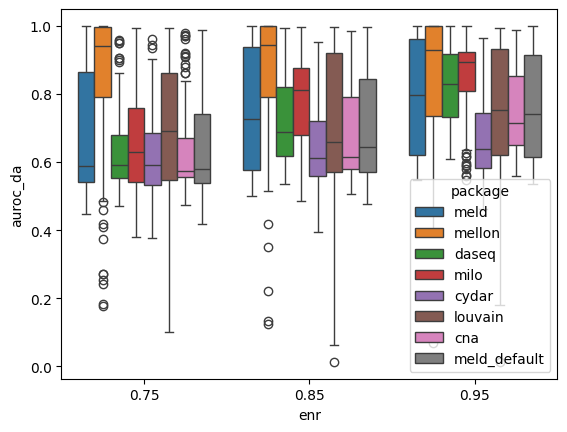

In [57]:
performance_dict= get_performance("branch","auroc_da")

[0.799361287169418, 0.877037015191035, 0.9104695724226974]
[0.9399753812697342, 0.9446816234569047, 0.9279849296372866]
[0.7754154593662442, 0.8621053994606974, 0.9308034080477792]
[0.7797011007340922, 0.8805312994878611, 0.930334629507052]
[0.747924992615367, 0.8458937349809899, 0.8868773423405956]
[0.7594422872862339, 0.8030901623979829, 0.8666024490588983]
[0.7770822349840552, 0.8138488842009939, 0.8797962197872338]
[0.7819052281252177, 0.8368099379236132, 0.876894176951346]


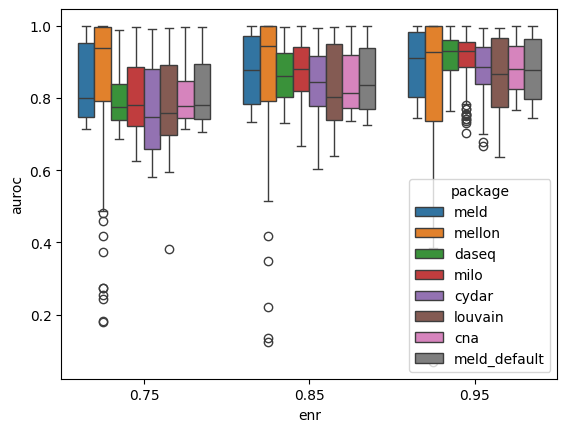

In [58]:
performance_dict= get_performance("branch","auroc")

[-1.1011515809310546, -0.8801111302601183, -0.6247628970668921]
[-1.7501441511217446, -1.3989594184364194, -1.0863573903305244]
[-1.1146703276938732, -0.9887305156546439, -0.7741388020738169]
[1.2543417967123567, 1.331145671577541, 1.4688245226763723]
[-0.4590931155657953, -0.440251004631799, -0.38123707935594603]
[-0.4503101459003501, -0.42834788575157323, -0.38226078047735323]
[-1.0381686188383092, -0.8552362741351387, -0.6270033996214779]
[-0.8971143460645534, -0.7945747344962908, -0.6216300090317683]


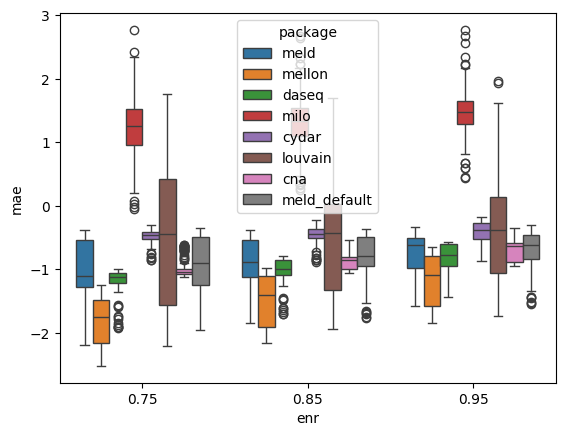

In [59]:
performance_dict= get_performance("branch","mae")

[-1.7950615978494682, -1.4756662025571834, -1.0462022893638259]
[-2.6139894937739507, -1.8856637041889723, -1.1980825755631548]
[-1.9545055615368847, -1.5875105296356815, -1.110556227726652]
[2.9772002166417364, 3.2100166341435346, 3.4669979340864154]
[-0.10071875881224669, -0.16559451726117413, -0.16742975835402582]
[-0.5873808178784623, -0.532568850768357, -0.4559893123709276]
[-1.6599268894900656, -1.2762539157013295, -0.8389556898850294]
[-1.4115781923424846, -1.192799821239459, -0.9368416399477988]


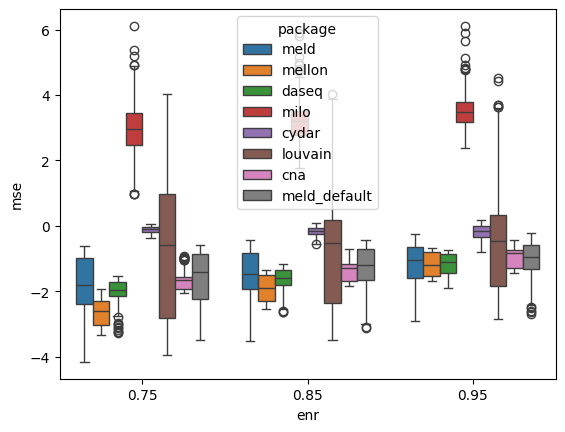

In [60]:
performance_dict= get_performance("branch","mse")

[-1.791543360421803, -1.5670375950557835, -1.1802272247532466]
[-2.714841254264225, -1.9637049355904743, -1.294518730629832]
[-1.9198254620477848, -1.6099525875910627, -1.2040905863306057]
[2.9401711036232214, 3.088938927665266, 3.302802463956559]
[-0.06461953461105578, -0.12461579112946906, -0.1572117136589878]
[-0.4466326343995413, -0.6202996925572432, -0.372469668759038]
[-1.7398715439356247, -1.4010239802501514, -1.0019167793618373]
[-1.3574429901007081, -1.2162576282725732, -0.9454631583402707]


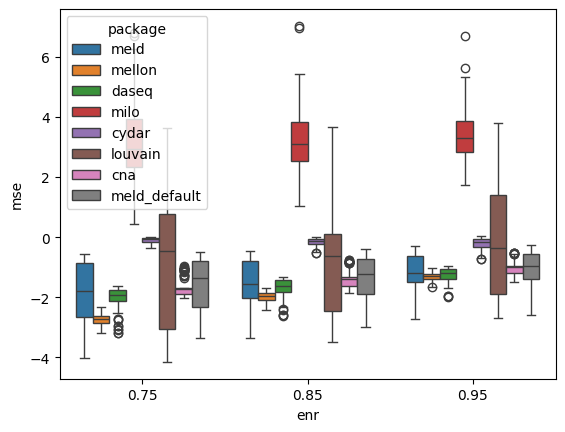

In [61]:
performance_dict= get_performance("linear","mse")

[-1.837100145238399, -1.1799988782662367, -0.9798546127813363]
[-2.0610329650346695, -1.3849332076065894, -0.5226581497681123]
[-1.818650273538708, -1.3888305453684429, -0.7526149323727247]
[2.5394452798340352, 2.920148301890636, 3.502854300094365]
[-0.2564329417060424, -0.3275847819296021, -0.4109136061849959]
[-2.6546470584567916, -2.0832305652113314, -1.45920895003097]
[-1.536264230248263, -1.1473898968418268, -0.5418137583948519]
[-1.8644795744718956, -1.2856675605698469, -1.0696388104179668]


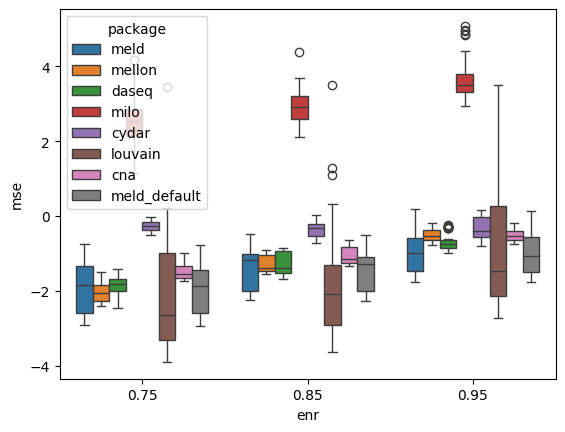

In [62]:
performance_dict= get_performance("cluster","mse")

[-1.0198956316092942, -0.7974963621439252, -0.7618567280339074]
[-1.49423591575827, -1.2369291579773696, -0.8787829008963967]
[-1.0807100010606479, -0.8935909454066678, -0.6520966544615073]
[0.9856744796332998, 1.1767529585671483, 1.3990417178517598]
[-0.4876751965848308, -0.47357029920760896, -0.42819108226520375]
[-1.542639988903495, -1.2785876345813352, -0.9370024356220688]
[-0.9681482739928056, -0.7143676023031326, -0.4388708830293377]
[-1.0208191002433482, -0.8693693186164164, -0.7820473322554781]


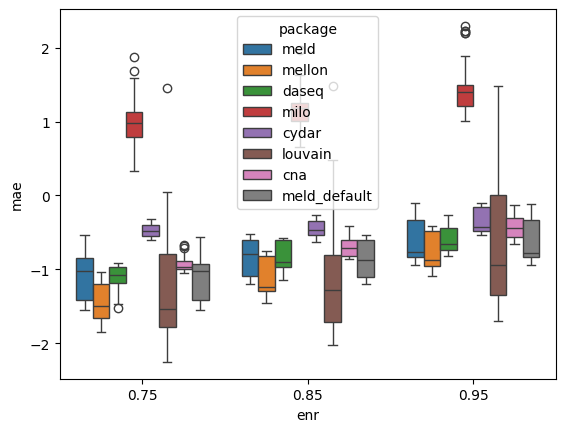

In [63]:
performance_dict= get_performance("cluster","mae")

[-1.1223927394520585, -0.9920469439891824, -0.750725086130013]
[-1.834059445412914, -1.4865004599573541, -1.174889037976337]
[-1.1013986705522523, -0.9820101441335445, -0.794863793109641]
[1.2742471578281427, 1.3053503180661679, 1.372481916394943]
[-0.42802751023230096, -0.42461669879093844, -0.38748566376268156]
[-0.40150361650386984, -0.5037746949089758, -0.30346170454907867]
[-1.0596613848402072, -0.9273506985595918, -0.7414898229314214]
[-0.8343304719959324, -0.7999553538579149, -0.701508697458484]


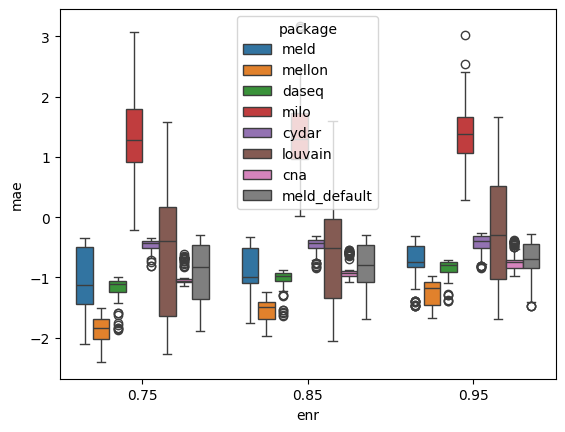

In [64]:
performance_dict= get_performance("linear","mae")

In [67]:
metrics = ["auroc","auroc_neg","auroc_da","auprc_da","auprc_neg","auprc","mae","mse","pearson",
           "spearman","kendall"]
len(metrics)

11

In [72]:
default_palette = sns.color_palette("colorblind")
designed_palette = list(default_palette)
designed_palette_final = [designed_palette[0],designed_palette[1],designed_palette[2],designed_palette[3],designed_palette[4],designed_palette[5],designed_palette[6],designed_palette[7]]

[0.9785498841258196, 0.9881369777534805, 0.9947514020487763]
[0.9154203765286418, 0.9337675535008131, 0.9477819702104369]
[0.8571727240161027, 0.919981498612396, 0.954685392207931]
[0.8272264728831127, 0.8787208802330129, 0.9019625641877119]
[0.5, 0.5, 0.5]
[0.9632849025149601, 0.9846901093526186, 0.9908306257205743]
[0.7840449839750291, 0.85311977749161, 0.8860193532303199]
[0.9607350317874761, 0.9779463592283749, 0.9840016495038133]
[0.9372667164443435, 0.954201421260609, 0.966210335597655]
[0.9785498841258196, 0.9881369777534805, 0.9947514020487763]
[0.9154203765286418, 0.9337675535008131, 0.9477819702104369]
[0.8571727240161027, 0.919981498612396, 0.954685392207931]
[0.8272264728831127, 0.8787208802330129, 0.9019625641877119]
[0.5, 0.5, 0.5]
[0.9632849025149601, 0.9846901093526186, 0.9908306257205743]
[0.7840449839750291, 0.85311977749161, 0.8860193532303199]
[0.9607350317874761, 0.9779463592283749, 0.9840016495038133]
[0.9372667164443435, 0.954201421260609, 0.966210335597655]
[0.8

/loc/scratch/11397987/ipykernel_13318/3877851471.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, _ = pearsonr(y_true, y_pred)


[0.8766019203281696, 0.939150681413387, 0.9517250489345647]
[0.6472098389251157, 0.7560422880525923, 0.8180053167943298]
[0.5985035876939508, 0.7387497233449949, 0.8116261538148163]
[0.5456671357297098, 0.6690760673266334, 0.7546786138558395]
[nan, nan, nan]
[0.8383676597692806, 0.8898964096943435, 0.9175546296605994]
[0.4274084091482977, 0.49958662760256634, 0.5483134016579257]
[0.8348577234396157, 0.9094720560938533, 0.9465807515117974]
[0.7003393158100177, 0.774461249879898, 0.8177476451204508]


/home/ryang/.conda/envs/DiffAbundance/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/ryang/.conda/envs/DiffAbundance/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/ryang/.conda/envs/DiffAbundance/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/loc/scratch/11397987/ipykernel_13318/1367063689.py:8: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, _ = spearmanr(ground_truth_ranks, predicted_ranks)


[0.46926266178244724, 0.5264411273393979, 0.6143522117111504]
[0.40579013758915794, 0.43849608755370817, 0.5170380013268978]
[0.3523774563338214, 0.4039971957617279, 0.46760534247120605]
[0.3233292232316187, 0.39297678880610154, 0.4430527765281451]
[nan, nan, nan]
[0.4574972161044828, 0.5129225518242766, 0.6105728410048888]
[0.2633221080341708, 0.32786562468738883, 0.3817968894470558]
[0.43256686248829973, 0.485993383274549, 0.5576654101487183]
[0.4583202726528047, 0.470841181049621, 0.5115405790353881]


/home/ryang/.conda/envs/DiffAbundance/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/ryang/.conda/envs/DiffAbundance/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/ryang/.conda/envs/DiffAbundance/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


[0.3381016135484731, 0.3842486375961239, 0.43935756767569006]
[0.2806016802240298, 0.29426373294217006, 0.36405067342312303]
[0.23984061874916654, 0.2817904609503489, 0.3320803307107614]
[0.2220227026373098, 0.27154970889466284, 0.30741821268325553]
[nan, nan, nan]
[0.3392587033906341, 0.3737327106703908, 0.44726706685733353]
[0.17970054673956526, 0.22567929946215048, 0.26269358581144153]
[0.3035281859803529, 0.3446535271369515, 0.3991902920389385]
[0.32151010356936477, 0.33922282971062806, 0.3779248077521447]


/home/ryang/.conda/envs/DiffAbundance/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/ryang/.conda/envs/DiffAbundance/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/ryang/.conda/envs/DiffAbundance/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


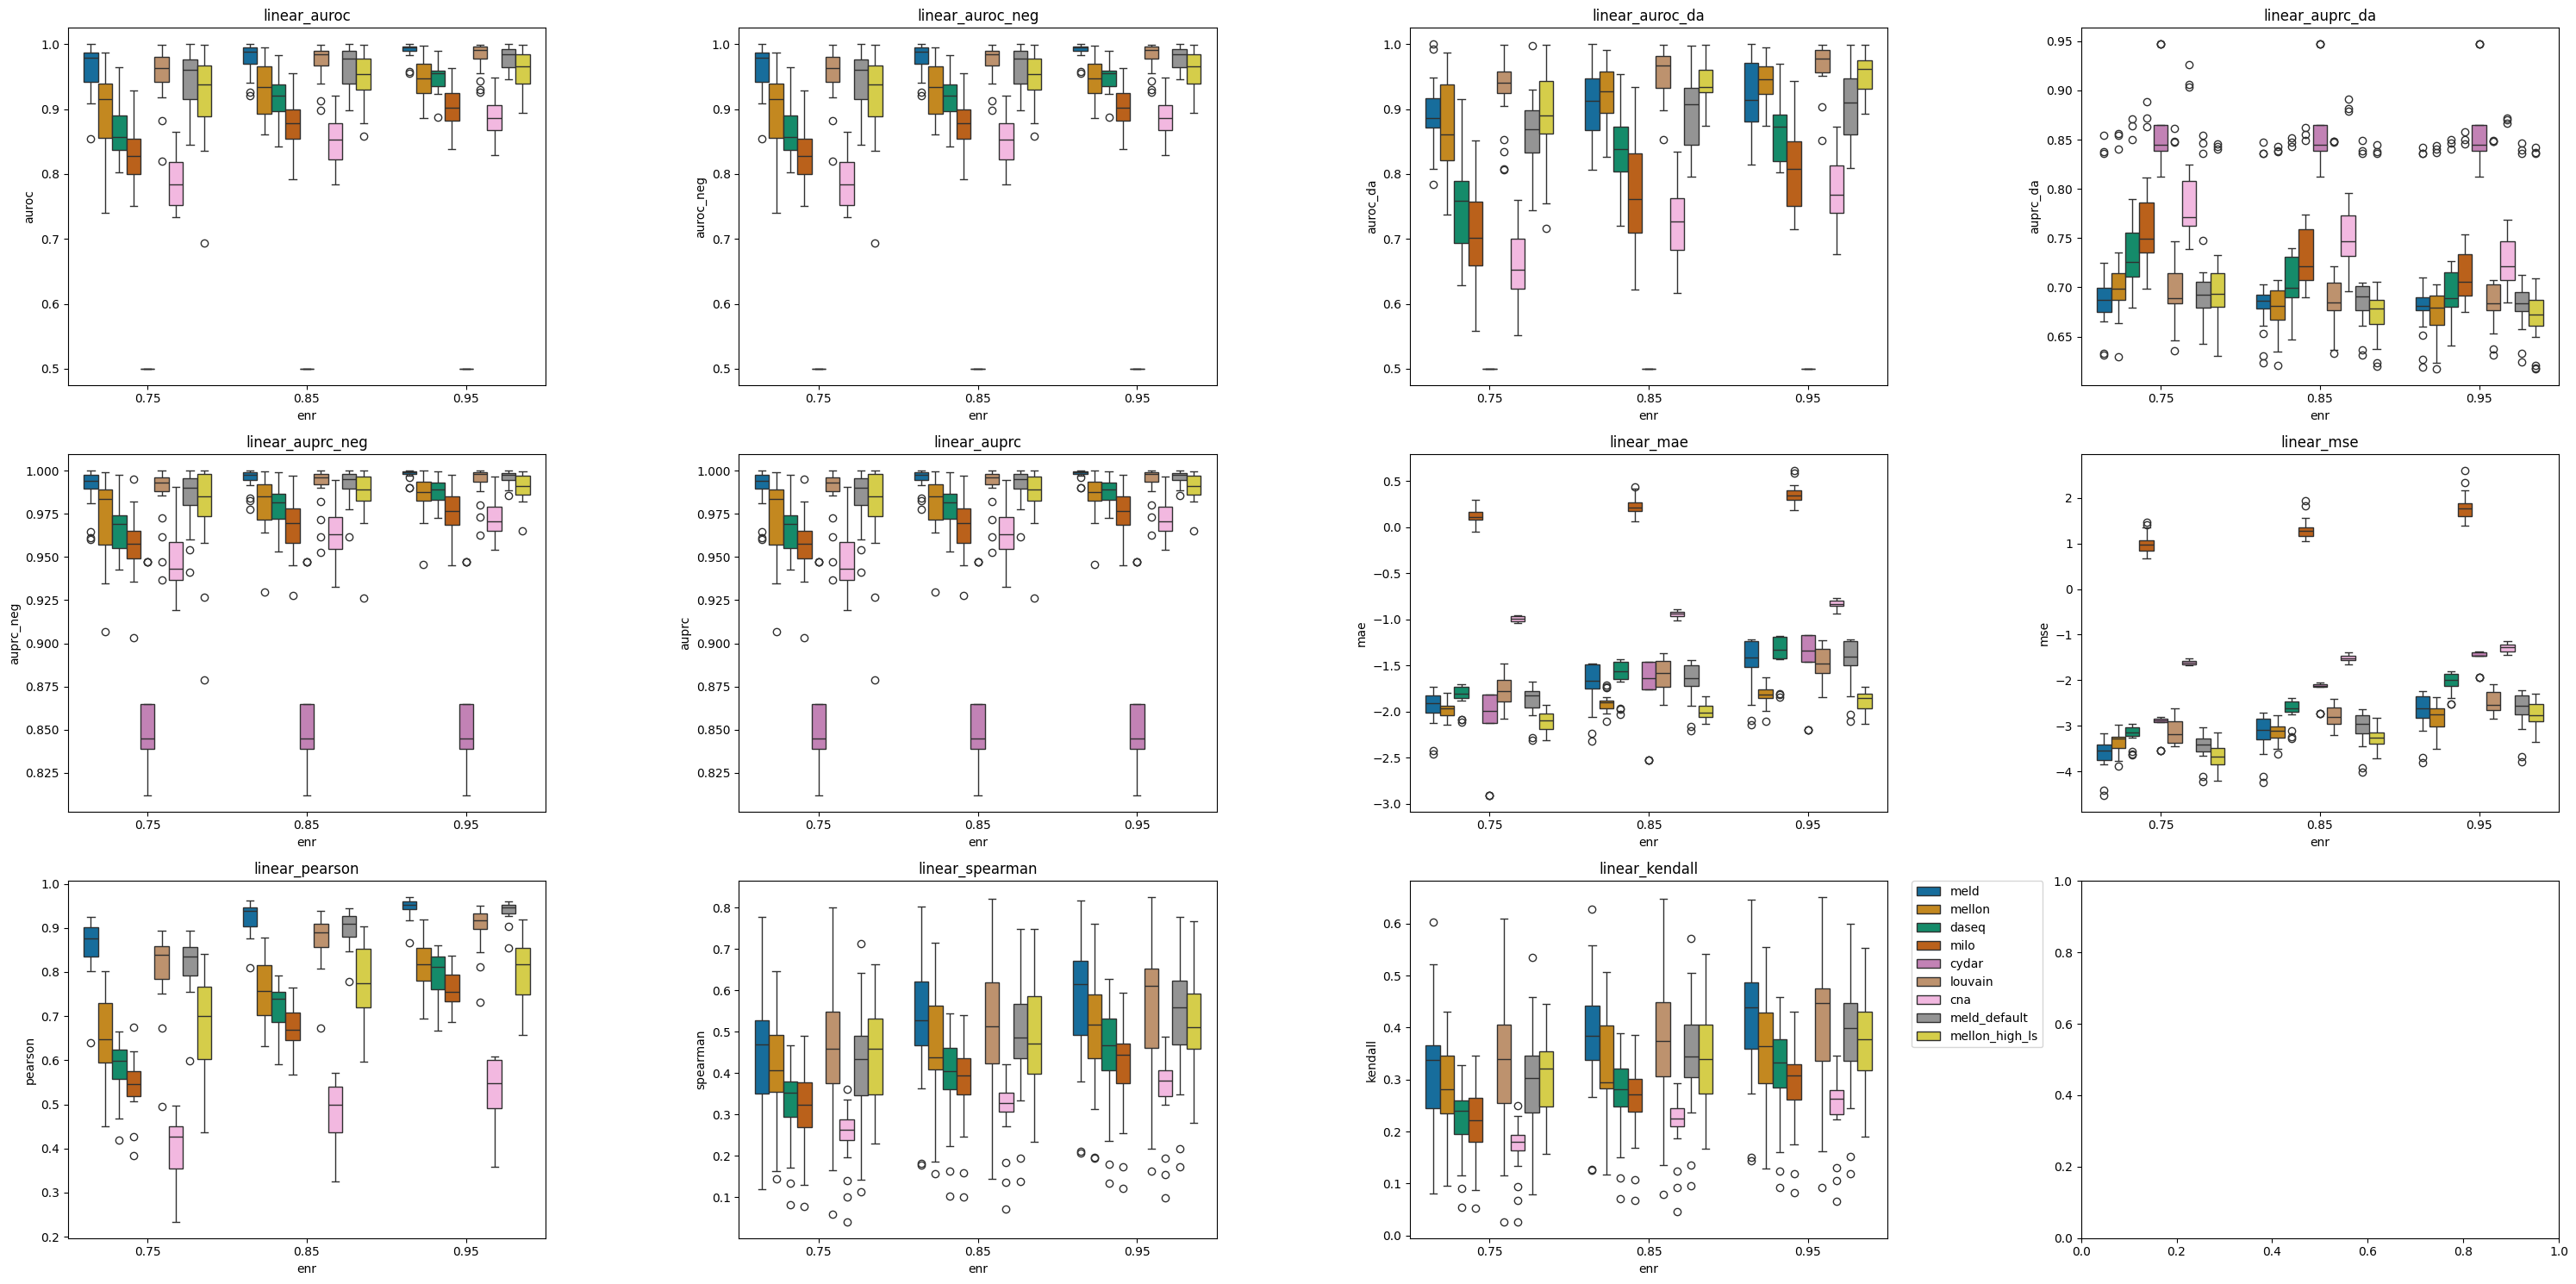

In [246]:
#"auprc_pos","auroc_pos"
# metrics = ["auroc","auroc_neg","auprc_neg","auprc","mae","mse","pearson",
#            "spearman","kendall"]
fig, axs = plt.subplots(3, (len(metrics) + 3 - 1) // 3, figsize=(30, 15))
axs = axs.flatten() 
metrics_data = {}
for i in range(len(metrics)):
    general_performance_df = get_performance("linear", metrics[i],axs[i],designed_palette_final)
    axs[i].set_title('linear_'+metrics[i])
    if i < len(metrics)-1:
        axs[i].get_legend().remove()
    else: 
        axs[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    metrics_data[metrics[i]] = general_performance_df
# plotting_boxplot_orig("branch", "auprc",axs[1])
# axs[1].set_title('branch auPRC')
# axs[1].get_legend().remove()

# plotting_boxplot_orig("cluster", "auprc",axs[2])
# axs[2].set_title('cluster auPRC')
# axs[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()

[0.5730972222222223, 0.582377093472045, 0.6486072222222222]
[0.511267144545311, 0.4467021156752613, 0.47925649959661576]
[0.5665227777777777, 0.5951380976538785, 0.6551205555555555]
[0.5395599443844219, 0.5156202777777777, 0.5512440545540735]
[0.5, 0.5, 0.5]
[0.5442763420798877, 0.5849386111111111, 0.6121052777777778]
[0.5301073374609023, 0.5264041685977632, 0.5647960043881568]
[0.5693972222222222, 0.5838783698082606, 0.650208888888889]
[0.49228027650529127, 0.4402340451109174, 0.44531701862396056]
[0.5730972222222223, 0.582377093472045, 0.6486072222222222]
[0.511267144545311, 0.4467021156752613, 0.47925649959661576]
[0.5665227777777777, 0.5951380976538785, 0.6551205555555555]
[0.5395599443844219, 0.5156202777777777, 0.5512440545540735]
[0.5, 0.5, 0.5]
[0.5442763420798877, 0.5849386111111111, 0.6121052777777778]
[0.5301073374609023, 0.5264041685977632, 0.5647960043881568]
[0.5693972222222222, 0.5838783698082606, 0.650208888888889]
[0.49228027650529127, 0.4402340451109174, 0.44531701862

/loc/scratch/11397987/ipykernel_13318/3877851471.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, _ = pearsonr(y_true, y_pred)


[0.07646337721212874, 0.1107360800562453, 0.10869908468256075]
[0.061909713082805136, 0.10157847936338667, 0.1242750154822878]
[0.13955216613304317, 0.19263385918106485, 0.16971113388347558]
[0.1554635656496423, 0.14900657448635574, 0.140965773479162]
[nan, nan, nan]
[0.033707170909919516, 0.13718126480786713, 0.11348243824968345]
[0.07521782007802924, 0.12644269871033756, 0.136065546605242]
[0.06847327079622895, 0.10119487506344466, 0.09931514733997521]
[0.03901218262278559, 0.09277778657925803, 0.10473480807524911]


/home/ryang/.conda/envs/DiffAbundance/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/ryang/.conda/envs/DiffAbundance/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/ryang/.conda/envs/DiffAbundance/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/loc/scratch/11397987/ipykernel_13318/1367063689.py:8: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, _ = spearmanr(ground_truth_ranks, predicted_ranks)


[0.26548645739030813, 0.2734027078284464, 0.30818733689507744]
[0.049352154308327824, 0.04072809520732901, 0.032259882492591714]
[0.20028966015252153, 0.25862421227888904, 0.2945404110785505]
[0.0780455747619993, 0.10912865533606461, 0.17452295128165407]
[nan, nan, nan]
[0.23185705013280156, 0.2892564129119663, 0.26612340946279706]
[0.10227624021469534, 0.13128436063952514, 0.17084661938149023]
[0.27654481708433704, 0.2752956091702558, 0.32182581765633833]
[0.11236353926645103, 0.08835078303851619, -0.02296951511546465]


/home/ryang/.conda/envs/DiffAbundance/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/ryang/.conda/envs/DiffAbundance/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/ryang/.conda/envs/DiffAbundance/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


[0.18768597422913835, 0.1750535863762985, 0.19228465961329985]
[0.03173081937068599, 0.020520631784062687, 0.025649005804618995]
[0.1328217584016028, 0.1732789922193405, 0.19747066814869704]
[0.05506297967767712, 0.07653950714463797, 0.11225875052946911]
[nan, nan, nan]
[0.16551975874015531, 0.20334069064244412, 0.17220311644512123]
[0.06971910035266833, 0.08800515966132862, 0.11330561387619557]
[0.18848956403606273, 0.17295514113594884, 0.19829895846198178]
[0.08057689404855022, 0.05963141355508899, -0.005900676519424204]


/home/ryang/.conda/envs/DiffAbundance/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/ryang/.conda/envs/DiffAbundance/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/ryang/.conda/envs/DiffAbundance/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


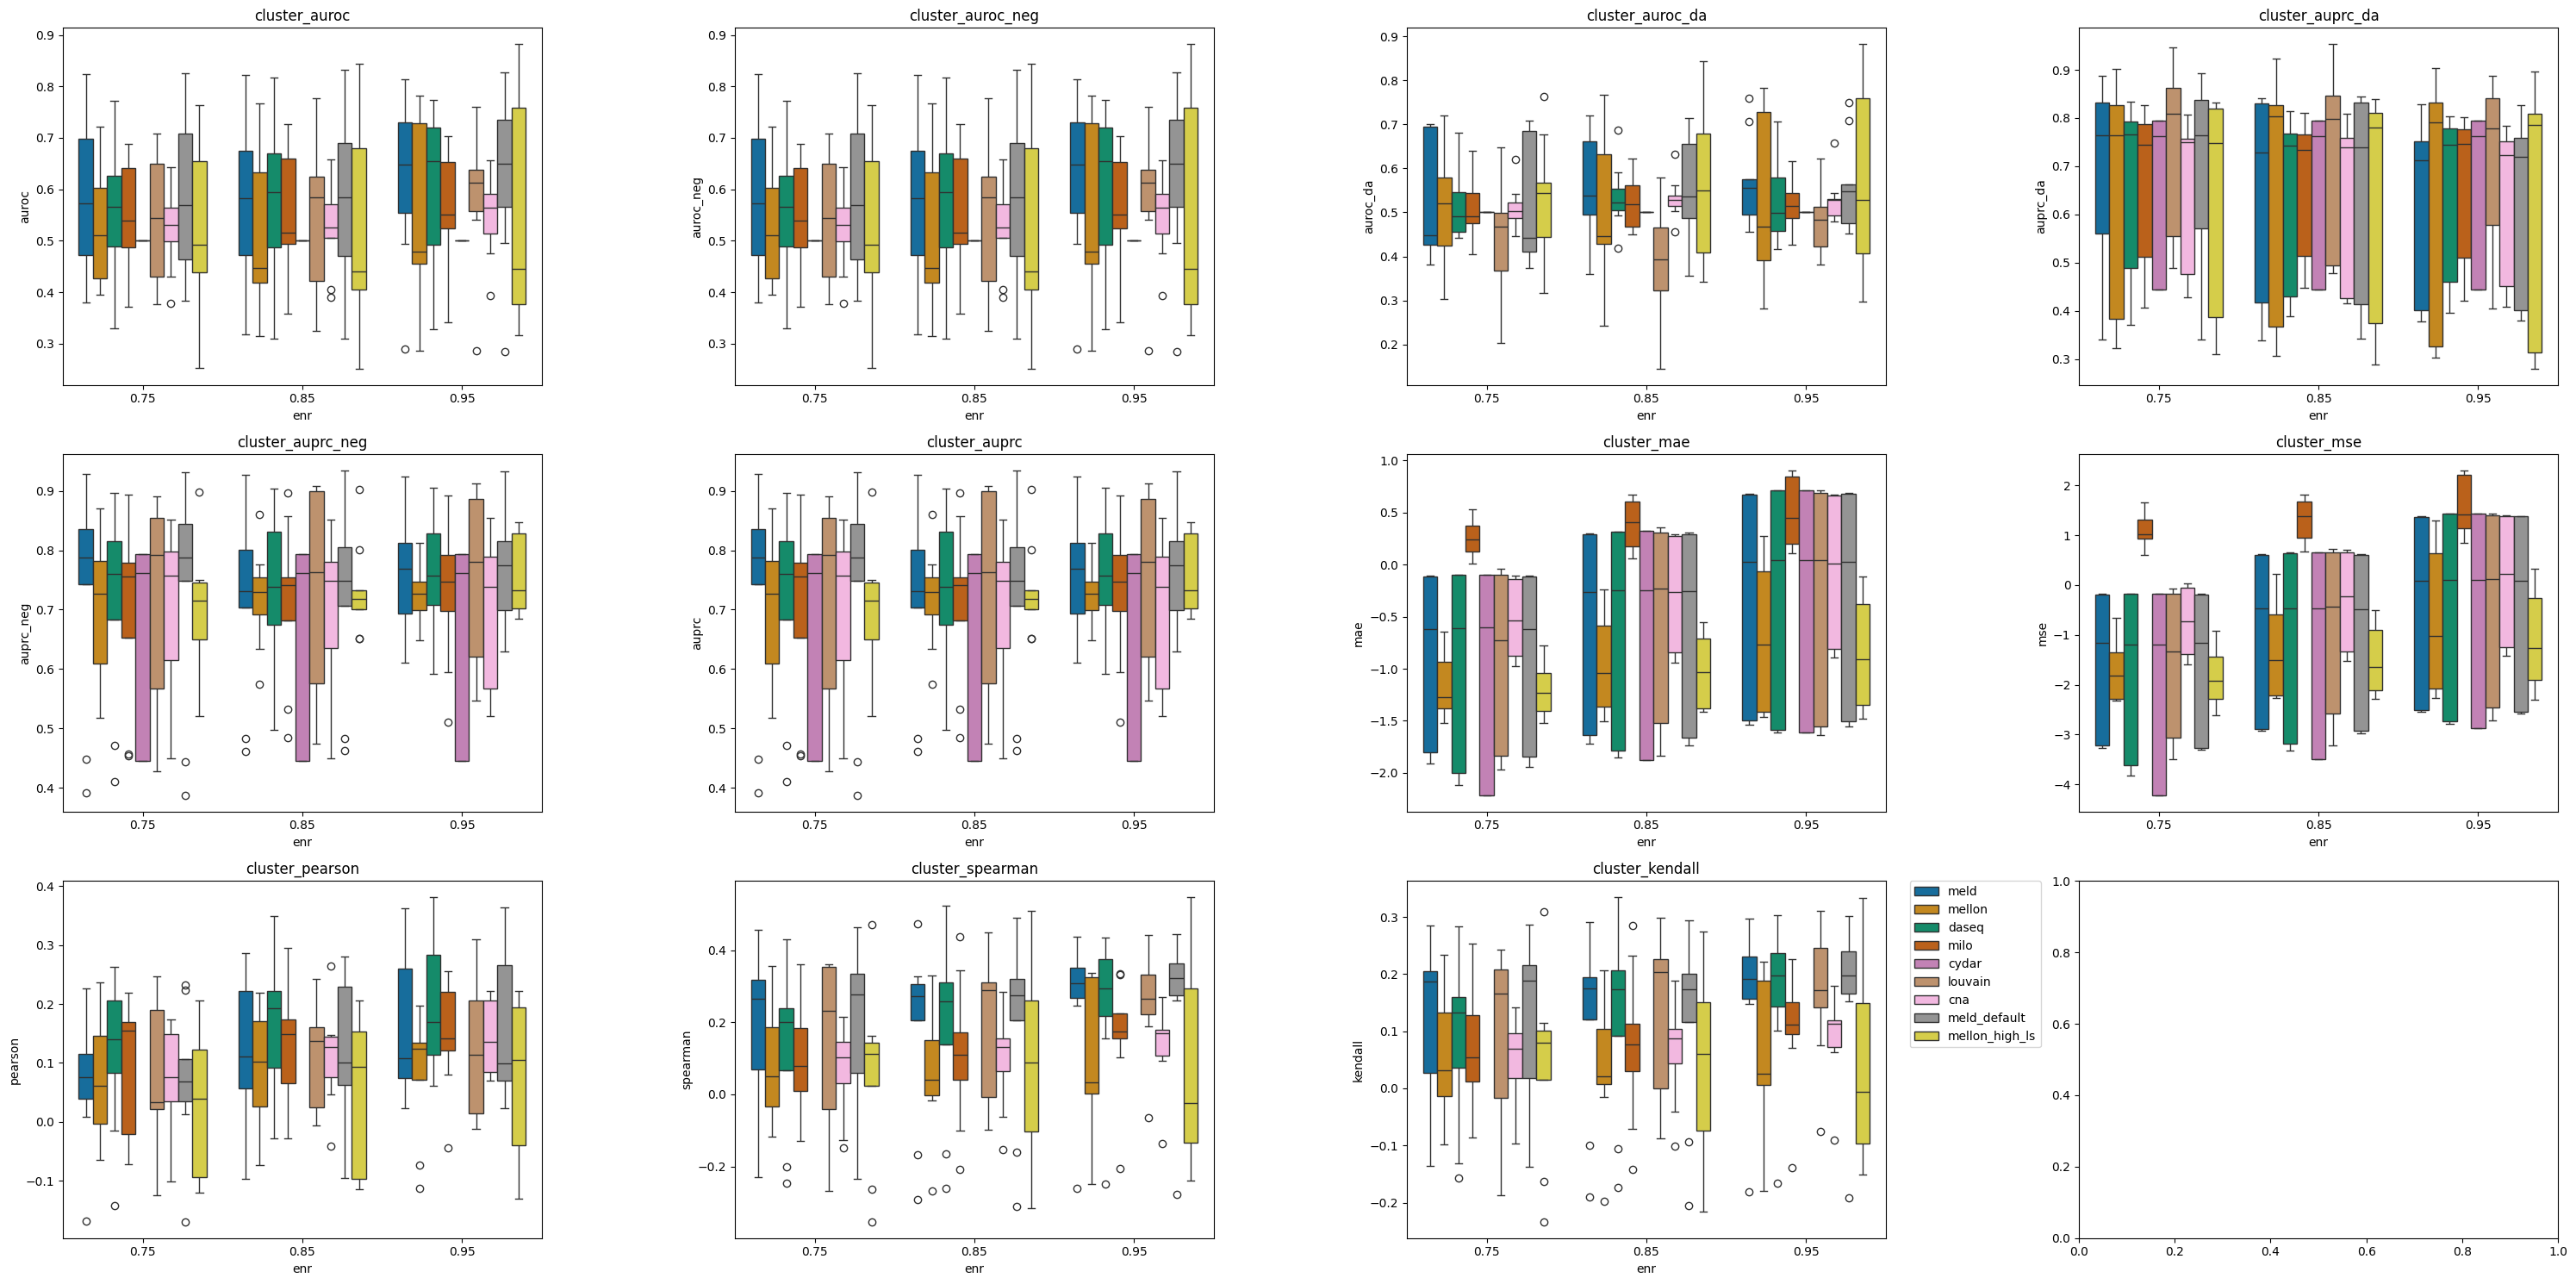

In [247]:
#"auprc_pos","auroc_pos"
# metrics = ["auroc","auroc_neg","auprc_neg","auprc","mae","mse","pearson",
#            "spearman","kendall"]
fig, axs = plt.subplots(3, (len(metrics) + 3 - 1) // 3, figsize=(30, 15))
axs = axs.flatten() 
metrics_data = {}
for i in range(len(metrics)):
    general_performance_df = get_performance("cluster", metrics[i],axs[i],designed_palette_final)
    axs[i].set_title('cluster_'+metrics[i])
    if i < len(metrics)-1:
        axs[i].get_legend().remove()
    else: 
        axs[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    metrics_data[metrics[i]] = general_performance_df
# plotting_boxplot_orig("branch", "auprc",axs[1])
# axs[1].set_title('branch auPRC')
# axs[1].get_legend().remove()

# plotting_boxplot_orig("cluster", "auprc",axs[2])
# axs[2].set_title('cluster auPRC')
# axs[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()

[0.9725264443316847, 0.9897214914674188, 0.9956452990503164]
[0.8522551146153373, 0.9017107266127278, 0.9264031805686437]
[0.8848081366503062, 0.9304448170720155, 0.9565658908106824]
[0.8279042086960791, 0.8786430954760184, 0.9026261857804202]
[0.5, 0.5, 0.5]
[0.9601578411427665, 0.9749457907694025, 0.9786566129191923]
[0.7968296592824952, 0.8606077768988881, 0.8972158532669405]
[0.9627741874327391, 0.9851910734488403, 0.9921010400916339]
[0.8308858380103081, 0.8931479558423274, 0.91191848896979]
[0.9725264443316847, 0.9897214914674188, 0.9956452990503164]
[0.8522551146153373, 0.9017107266127278, 0.9264031805686437]
[0.8848081366503062, 0.9304448170720155, 0.9565658908106824]
[0.8279042086960791, 0.8786430954760184, 0.9026261857804202]
[0.5, 0.5, 0.5]
[0.9601578411427665, 0.9749457907694025, 0.9786566129191923]
[0.7968296592824952, 0.8606077768988881, 0.8972158532669405]
[0.9627741874327391, 0.9851910734488403, 0.9921010400916339]
[0.8308858380103081, 0.8931479558423274, 0.911918488969

/loc/scratch/11397987/ipykernel_13318/3877851471.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, _ = pearsonr(y_true, y_pred)


[0.7980954444053866, 0.8723207330309197, 0.9045555762237567]
[0.48871493456073456, 0.6676888425758158, 0.76511024167457]
[0.5390862631492491, 0.6799940427515703, 0.7592637285490318]
[0.44159902806911566, 0.594333505652042, 0.7005062364597154]
[nan, nan, nan]
[0.7213276607390859, 0.7949785233696289, 0.8137686199608928]
[0.36014504682868986, 0.44634849305503704, 0.49697111825555107]
[0.7665855139492597, 0.8575278693666674, 0.9011353988441801]
[0.401262498911895, 0.5799377057674002, 0.6434571854461806]


/home/ryang/.conda/envs/DiffAbundance/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/ryang/.conda/envs/DiffAbundance/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/ryang/.conda/envs/DiffAbundance/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/loc/scratch/11397987/ipykernel_13318/1367063689.py:8: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, _ = spearmanr(ground_truth_ranks, predicted_ranks)


[0.5664957116745903, 0.6476586453557092, 0.6998133757975711]
[0.3983565480525608, 0.47478718791799446, 0.4982870938006594]
[0.3629005381920095, 0.45476097478330624, 0.5447556706978786]
[0.3043419066028145, 0.39439881554167416, 0.456629601862103]
[nan, nan, nan]
[0.5749689406300087, 0.6190550864721385, 0.6636264535169761]
[0.2879648865558202, 0.35932242061017633, 0.4363218647666109]
[0.5441153477851617, 0.6186002493191154, 0.6635858647250821]
[0.4143288004680675, 0.5021452783456938, 0.5294974421030656]


/home/ryang/.conda/envs/DiffAbundance/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/ryang/.conda/envs/DiffAbundance/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/ryang/.conda/envs/DiffAbundance/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


[0.405980815219807, 0.4841829221674001, 0.5304458372227407]
[0.2776458372227408, 0.3402262701693559, 0.3637067697915277]
[0.24878485131350847, 0.31832866604436144, 0.38675535404720623]
[0.2071363892625837, 0.2700621388984946, 0.31739120352566763]
[nan, nan, nan]
[0.41830981326712924, 0.44995668795922983, 0.4905400897849003]
[0.1943183535582522, 0.24509941770013777, 0.30288813619593724]
[0.3936467617904609, 0.45837446770680534, 0.49937716139929766]
[0.2763994843756945, 0.36378393563586253, 0.3742037782815486]


/home/ryang/.conda/envs/DiffAbundance/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/ryang/.conda/envs/DiffAbundance/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/ryang/.conda/envs/DiffAbundance/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


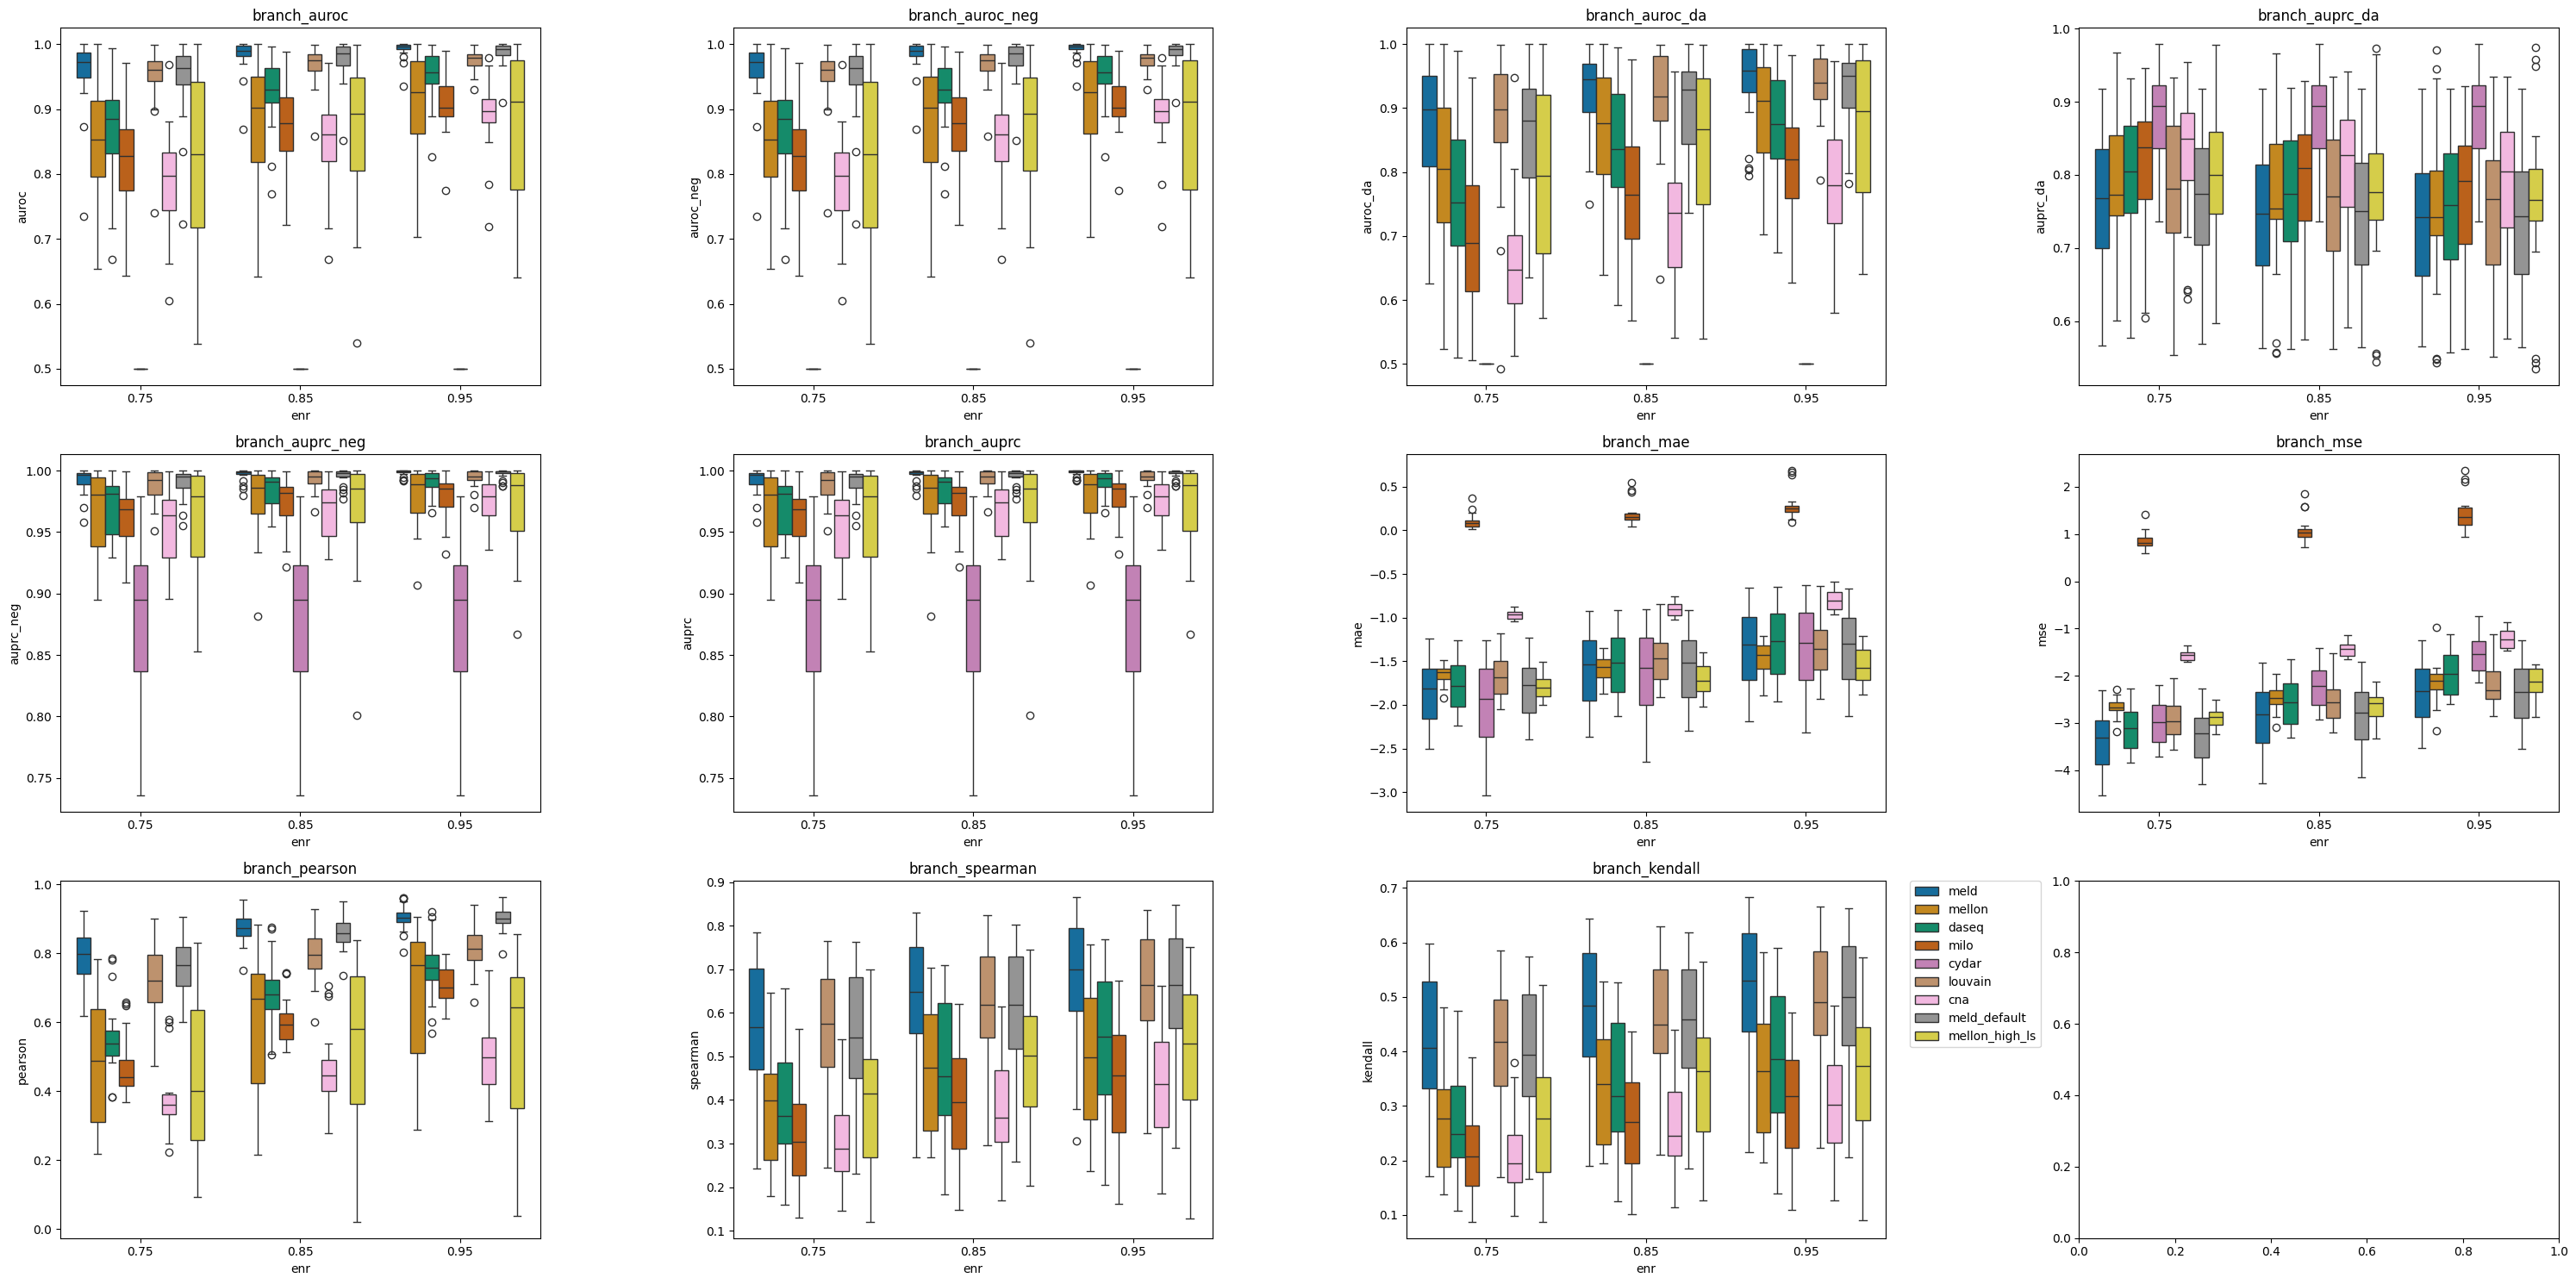

In [248]:
#"auprc_pos","auroc_pos"
# metrics = ["auroc","auroc_neg","auprc_neg","auprc","mae","mse","pearson",
#            "spearman","kendall"]
fig, axs = plt.subplots(3, (len(metrics) + 3 - 1) // 3, figsize=(30, 15))
axs = axs.flatten() 
metrics_data = {}
for i in range(len(metrics)):
    general_performance_df = get_performance("branch", metrics[i],axs[i],designed_palette_final)
    axs[i].set_title('branch_'+metrics[i])
    if i < len(metrics)-1:
        axs[i].get_legend().remove()
    else: 
        axs[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    metrics_data[metrics[i]] = general_performance_df
# plotting_boxplot_orig("branch", "auprc",axs[1])
# axs[1].set_title('branch auPRC')
# axs[1].get_legend().remove()

# plotting_boxplot_orig("cluster", "auprc",axs[2])
# axs[2].set_title('cluster auPRC')
# axs[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()

In [24]:
### Check the new version mellon produced results

In [70]:
def get_performance_batch(ds,metrics,ax,designed_palette_final):
    # ,ax,designed_palette_final
    result_dict,ground_truth_dict = get_results(ds)
    #performance_dict,ground_truth_dict
    performance_dict = {}
    if ds == "branch":
        pop_list = ["M1","M2","M3","M4","M5","M6","M7","M8"]
    elif ds == "linear":
        pop_list = ["M1","M2","M3","M4","M5","M6","M7"]
    elif ds == "cluster" or ds == "cluster_balanced":
        pop_list = ["M1","M2","M3"]
    elif ds == "covid19-pbmc":
        pop_list = ["B","RBC","PB","CD14_Monocyte","CD8_T","CD4_T","Platelet","NK","Granulocyte","CD16_Monocyte","gd_T","pDC","DC"]
    elif ds == "pancreas":
        pop_list = ["delta_cell", "alpha_cell", "gamma_cell", "acinar_cell", "beta_cell", "ductal_cell", "epsilon_cell"]
    elif ds == "bcr-xl":
        pop_list = ["CD4_T-cells", "NK_cells", "CD8_T-cells", "monocytes", "B-cells_IgM-", "DC", "B-cells_IgM+", "surface-"]
    elif ds == "levine32":
        pop_list = ["pDCs", "CD4_T_cells", "CD8_T_cells", "Pre_B_cells", "Mature_B_cells", "Monocytes", "Basophils"]
        
        #,"0.75","1","1.25","1.5"
    performance_dict = {}
     ## for real datasets, change the below line from ["0", "0.75","1","1.25","1.5"] to just ["0"]
    for i in ["0","0.75","1","1.25","1.5"]:
        for j in ["43","44","45"]:
                for l in ["0.75","0.85","0.95"]:
                    #"daseq","milo",,"cydar","louvain"
                    for w in pop_list:
                        ground_truth_df = ground_truth_dict[i+"_"+j+"_"+w+"_"+l]
                        result_df = result_dict[i+"_"+j+"_"+w+"_"+l]
                        
#                         _, idx_1 = np.unique(ground_truth_df['lfc_truth'], return_index=True)
#                         mask_1 = np.zeros(len(ground_truth_df), dtype=bool)
#                         mask_1[idx_1] = True
                        
                        

                        
#                         ground_truth_df = ground_truth_df[mask_1]
#                         result_df = result_df[mask_1]
                        #for k in ["meld","mellon","cna","meld_default","mellon_high_ls"]:

                        for k in ["meld","mellon","daseq","milo","cydar","louvain","cna","meld_default"]:
#                             _, idx_2 = np.unique(result_df[k], return_index=True)
#                             mask_2 = np.zeros(len(result_df[k]), dtype=bool)
#                             mask_2[idx_2] = True
                            
#                             ground_truth_df = ground_truth_df[mask_2]
#                             result_df = result_df[mask_2]
                            
                            if metrics == "auroc":
                                score = modified_auroc(ground_truth_df, result_df,k)["mean_auroc"]
                            elif metrics == "auroc_neg":
                                score = modified_auroc(ground_truth_df, result_df,k)["neg_auroc"]
                            elif metrics == "auroc_da":
                                score = modified_auroc(ground_truth_df, result_df,k)["da_auroc"]
                            elif metrics == "auprc_neg":
                                score = modified_auprc(ground_truth_df, result_df,k)["neg_auprc"]
                            elif metrics == "auprc_da":
                                score = modified_auprc(ground_truth_df, result_df,k)["da_auprc"]
                            elif metrics == "auprc":
                                score = modified_auprc(ground_truth_df, result_df,k)["mean_auprc"]
                            elif metrics == "mae":
                                score = np.log(calculate_mae(ground_truth_df, result_df,k) + 1e-16)
                            elif metrics == "mse":
                                score = np.log(calculate_mse(ground_truth_df, result_df,k) + 1e-16)
                            elif metrics == "pearson":
                                score = calculate_pearson_correlation(ground_truth_df, result_df,k)
                            # elif metrics == "r2":
                            #     score = calculate_r2(ground_truth_df, result_df,k)
                            elif metrics == "spearman":
                                score = compare_ranks_spearman(ground_truth_df, result_df,k)
                            elif metrics == "kendall":
                                score = compare_ranks_kendall(ground_truth_df, result_df,k)
                            # elif metrics == "rbo":
                            #     score = calculate_rbo(ground_truth_df, result_df,k)
                            performance_dict[j+"_"+l+"_"+w+"_"+i+"_"+k] = score
                            
    general_performance_df = pd.DataFrame()
    for k in ["meld","mellon","daseq","milo","cydar","louvain","cna","meld_default"]:
        auroc_ds_0 = []
        auroc_ds_75 = []
        auroc_ds_1 = []
        auroc_ds_125 = []
        auroc_ds_15 = []
        strings = k.split("_")
        for i in list(performance_dict.keys()):
            if len(strings) > 1:
                temp_k = strings[0]+"_"+strings[1]
                if "0_"+temp_k in i:
                    auroc_ds_0.append(performance_dict[i])
                elif "0.75_"+temp_k in i:
                    auroc_ds_75.append(performance_dict[i])
                elif "1_"+temp_k in i:
                    auroc_ds_1.append(performance_dict[i])
                elif "1.25_"+temp_k in i:
                    auroc_ds_125.append(performance_dict[i])
                elif "1.5_"+temp_k in i:
                    auroc_ds_15.append(performance_dict[i])
            elif len(strings) == 1:
                final_i = i.split("_")
                temp_k = final_i[-2] + "_" + final_i[-1]
                if "0_"+k == temp_k:
                    auroc_ds_0.append(performance_dict[i])
                elif "0.75_"+k == temp_k:
                    auroc_ds_75.append(performance_dict[i])
                elif "1_"+k == temp_k:
                    auroc_ds_1.append(performance_dict[i])
                elif "1.25_"+k == temp_k:
                    auroc_ds_125.append(performance_dict[i])
                elif "1.5_"+k == temp_k:
                    auroc_ds_15.append(performance_dict[i])
                
                
            

        performance = metrics
        auroc_df_0_ds = pd.DataFrame({performance:auroc_ds_0,"package": [k] * len(auroc_ds_0),"batch":["0"]* len(auroc_ds_0)})
        auroc_df_75_ds = pd.DataFrame({performance:auroc_ds_75,"package": [k] * len(auroc_ds_75),"batch":["0.75"]* len(auroc_ds_75)})
        auroc_df_1_ds = pd.DataFrame({performance:auroc_ds_1,"package": [k] * len(auroc_ds_1),"batch":["1"]* len(auroc_ds_1)})
        auroc_df_125_ds = pd.DataFrame({performance:auroc_ds_125,"package": [k] * len(auroc_ds_125),"batch":["1.25"]* len(auroc_ds_125)})
        auroc_df_15_ds = pd.DataFrame({performance:auroc_ds_15,"package": [k] * len(auroc_ds_15),"batch":["1.5"]* len(auroc_ds_15)})
        
    

#         median_75_ds = pd.Series(auroc_df_75_ds[performance]).median()

#         median_85_ds = pd.Series(auroc_df_85_ds[performance]).median()
#         median_95_ds = pd.Series(auroc_df_95_ds[performance]).median()

#         median_list = [median_75_ds,median_85_ds,median_95_ds]
#         print(median_list)
    
    
        auroc_df = pd.concat([auroc_df_0_ds,auroc_df_75_ds, auroc_df_1_ds,auroc_df_125_ds,auroc_df_15_ds], ignore_index=True)
        
        general_performance_df = pd.concat([general_performance_df,auroc_df],ignore_index = True)
    
    plot = sns.boxplot(x = general_performance_df['batch'], 
            y = general_performance_df[performance], 
            hue = general_performance_df['package'],palette = designed_palette_final,ax = ax)
    #,palette = designed_palette_final,ax = ax
    return general_performance_df

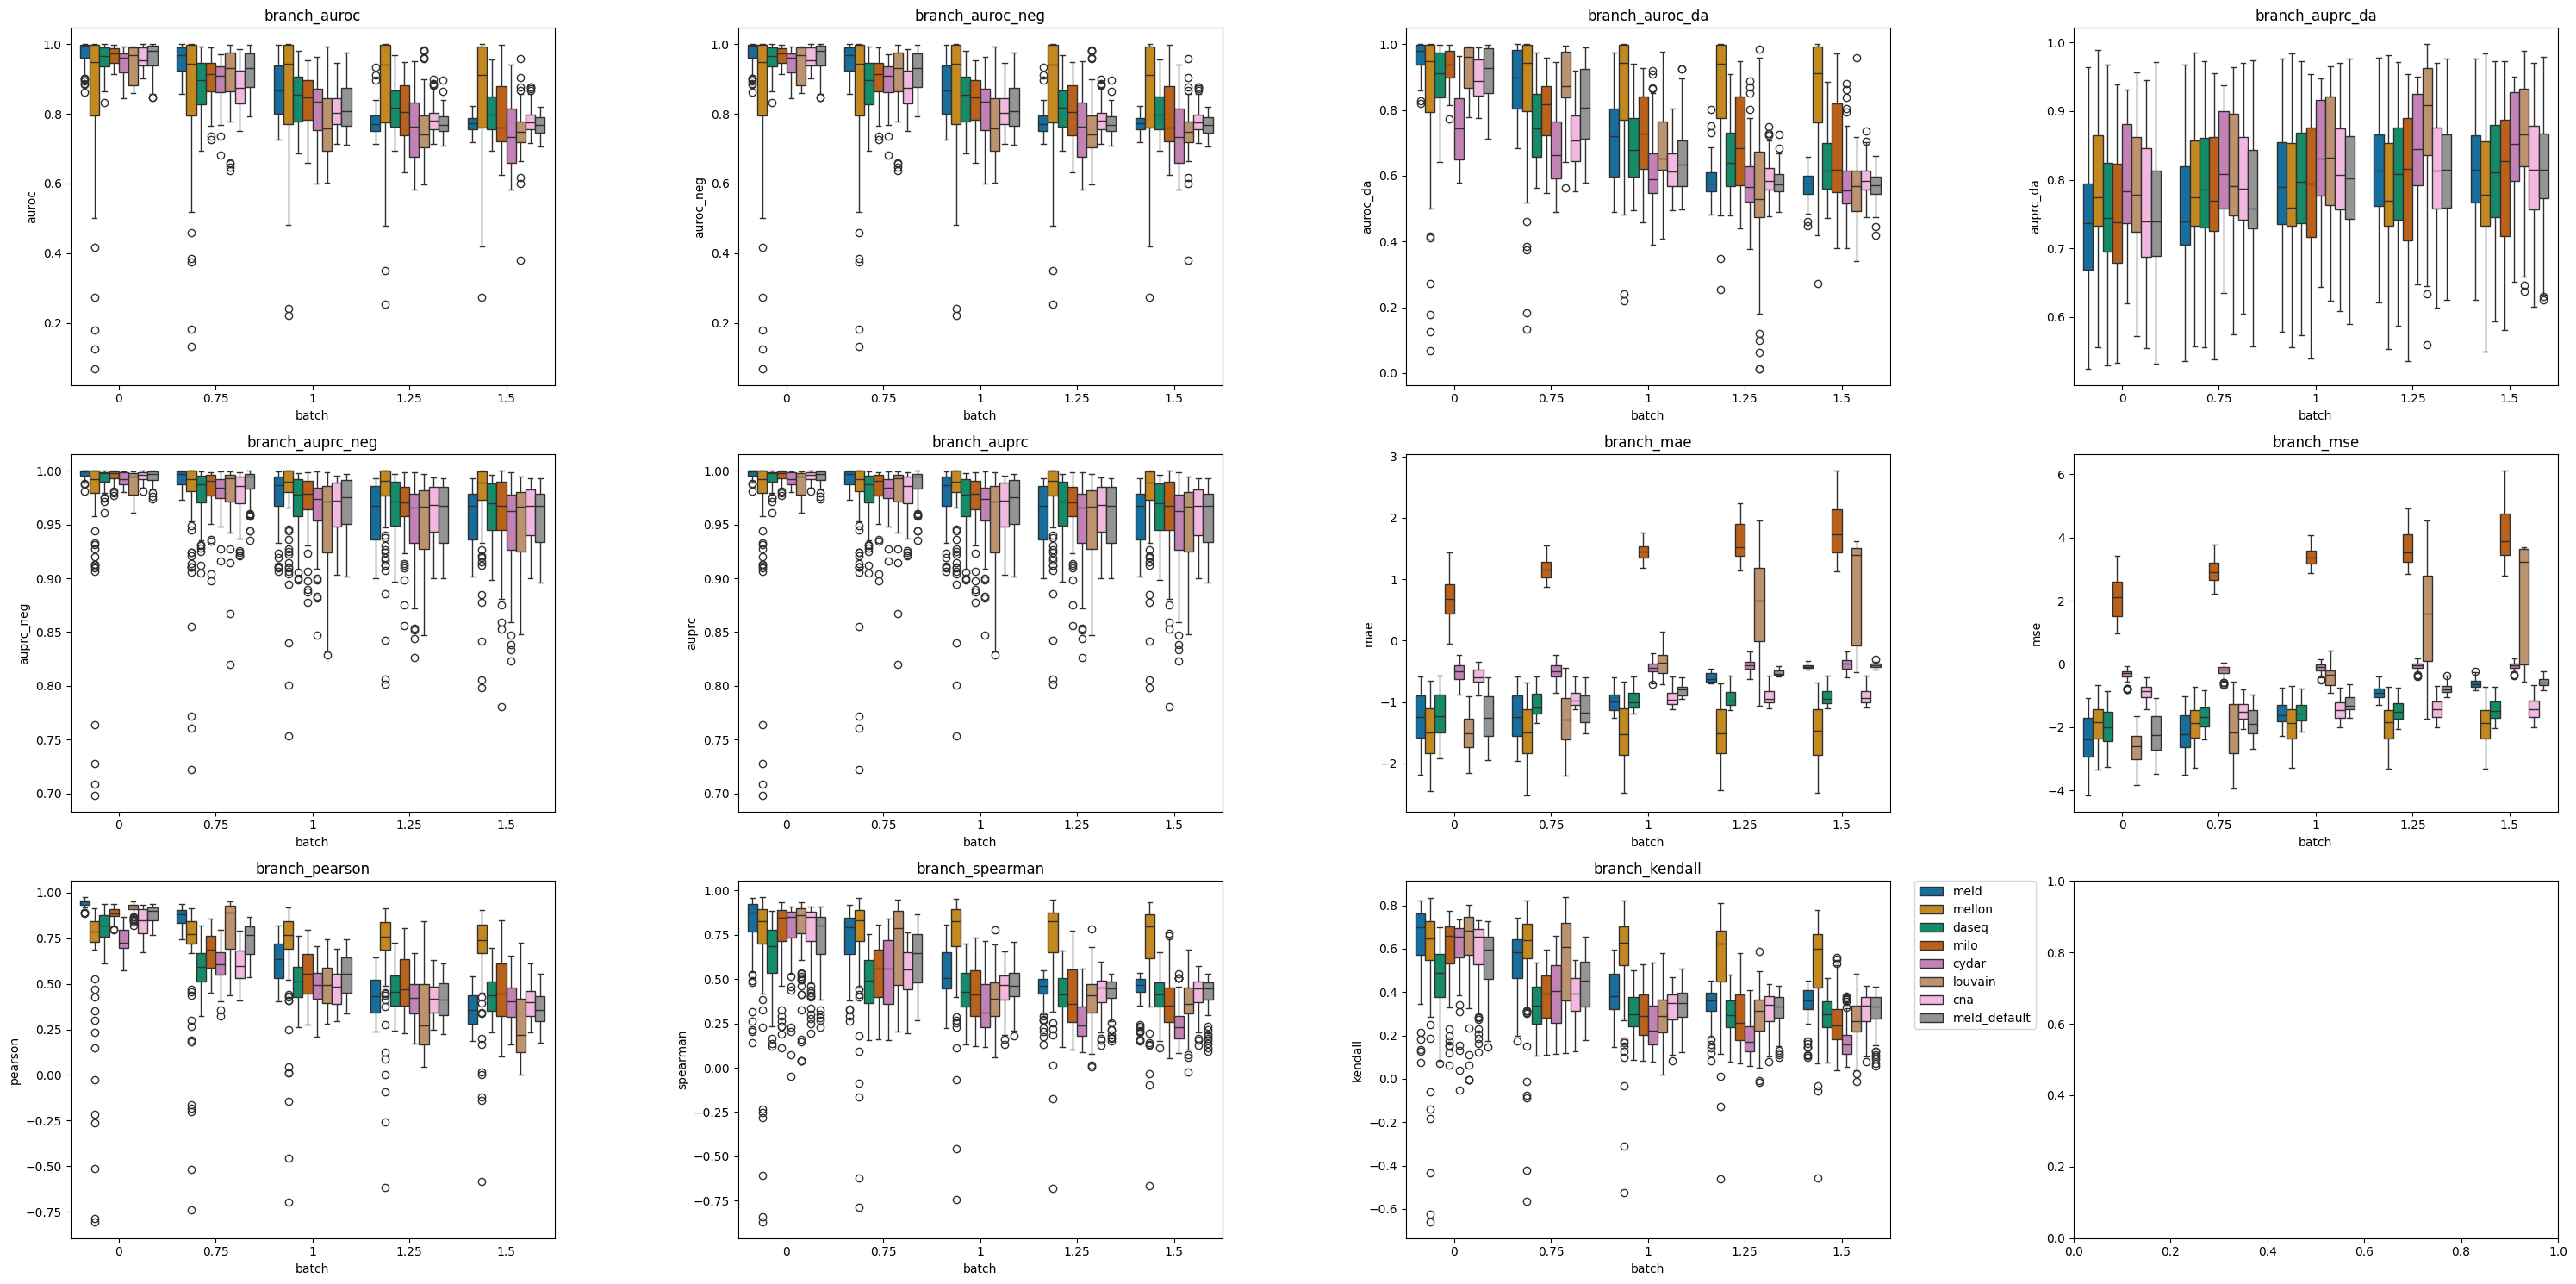

In [73]:
fig, axs = plt.subplots(3, (len(metrics) + 3 - 1) // 3, figsize=(30, 15))
axs = axs.flatten() 

#metrics_result = {}
for i in range(len(metrics)):
    get_performance_batch("branch", metrics[i],axs[i],designed_palette_final)
    axs[i].set_title('branch_'+metrics[i])
    if i < len(metrics)-1:
        axs[i].get_legend().remove()
    else: 
        axs[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    #metrics_result[metrics[i]] = general_performance_df
# plotting_boxplot_orig("branch", "auprc",axs[1])
# axs[1].set_title('branch auPRC')
# axs[1].get_legend().remove()

# plotting_boxplot_orig("cluster", "auprc",axs[2])
# axs[2].set_title('cluster auPRC')
# axs[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()

In [27]:
### dm = 10

## explorations

In [28]:
ad = sc.read_h5ad("/fh/fast/setty_m/user/ryang/differential_abundance/benchmarkDA/data/synthetic/branch/branch_anndata_dm_10.h5ad")

In [29]:
performance_dict,ground_truth_dict = get_results("branch")

In [30]:
ground_truth_dict['0_43_M1_0.75']

,true_labels,Condition1_prob,Condition2_prob,synth_labels,lfc_truth
C1,NotDA,0.502888,0.497112,Condition1,-0.011554
C2,NotDA,0.504778,0.495222,Condition2,-0.019112
C3,NotDA,0.505824,0.494176,Condition1,-0.023298
C4,NotDA,0.503284,0.496716,Condition2,-0.013136
C5,NotDA,0.505876,0.494124,Condition1,-0.023507
...,...,...,...,...,...
C7496,NotDA,0.505033,0.494967,Condition2,-0.020131
C7497,NotDA,0.503177,0.496823,Condition1,-0.012707
C7498,NotDA,0.503109,0.496891,Condition1,-0.012437
C7499,NotDA,0.503071,0.496929,Condition2,-0.012285


In [31]:
ad.obs["ground_truth_0_43_M1_0.75"]= ground_truth_dict['0_43_M1_0.75']["lfc_truth"]
ad.obs["truth_labels_0_43_M1_0.75"]= ground_truth_dict['0_43_M1_0.75']["true_labels"]
ad.obs["predicted_mellon_0_43_M1_0.75"]= performance_dict['0_43_M1_0.75']["mellon"]
ad.obs["predicted_meld_0_43_M1_0.75"]= performance_dict['0_43_M1_0.75']["meld"]
ad.obs["predicted_mellon_highls_0_43_M1_0.75"]= performance_dict['0_43_M1_0.75']["mellon_high_ls"]
ad.obs["predicted_meld_default_0_43_M1_0.75"]= performance_dict['0_43_M1_0.75']["meld_default"]

In [32]:
print(compare_ranks_spearman(ground_truth_dict['0_43_M1_0.75'],performance_dict['0_43_M1_0.75'],"meld"))
print(compare_ranks_spearman(ground_truth_dict['0_43_M1_0.75'],performance_dict['0_43_M1_0.75'],"meld_default"))
print(compare_ranks_spearman(ground_truth_dict['0_43_M1_0.75'],performance_dict['0_43_M1_0.75'],"mellon"))
print(compare_ranks_spearman(ground_truth_dict['0_43_M1_0.75'],performance_dict['0_43_M1_0.75'],"mellon_high_ls"))

0.3802432098603237
0.3342810716423301
0.21562017009102522
0.3948990820355392


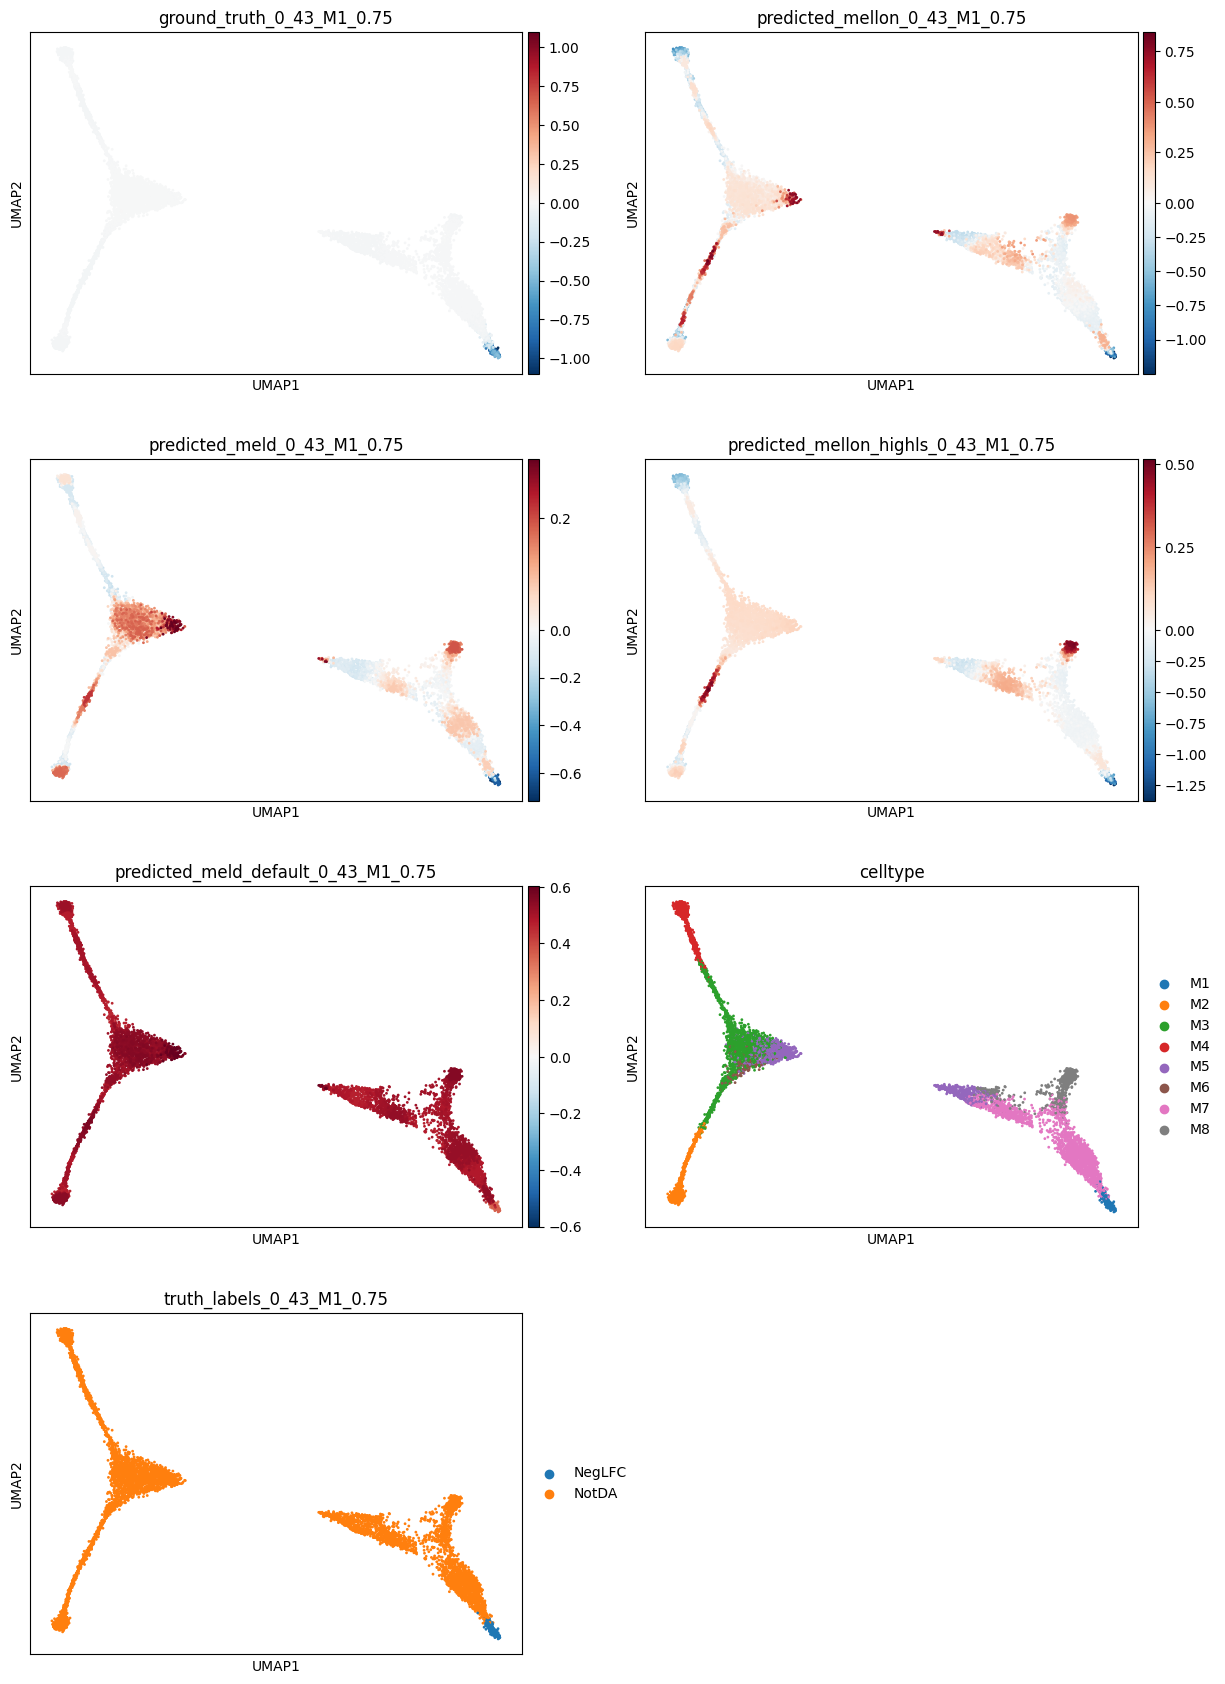

In [65]:
sc.pl.embedding(ad,"umap",color = ["ground_truth_0_43_M1_0.75","predicted_mellon_0_43_M1_0.75","predicted_meld_0_43_M1_0.75","predicted_mellon_highls_0_43_M1_0.75",
                                   "predicted_meld_default_0_43_M1_0.75","celltype","truth_labels_0_43_M1_0.75"], ncols = 2,cmap = "RdBu_r",vcenter = 0)

In [34]:
ad.obs["ground_truth_0_43_M3_0.75"]= ground_truth_dict['0_43_M3_0.75']["lfc_truth"]
ad.obs["truth_labels_0_43_M3_0.75"]= ground_truth_dict['0_43_M3_0.75']["true_labels"]
ad.obs["predicted_mellon_0_43_M3_0.75"]= performance_dict['0_43_M3_0.75']["mellon"]
ad.obs["predicted_meld_0_43_M3_0.75"]= performance_dict['0_43_M3_0.75']["meld"]
ad.obs["predicted_mellon_highls_0_43_M3_0.75"]= performance_dict['0_43_M3_0.75']["mellon_high_ls"]
ad.obs["predicted_meld_default_0_43_M3_0.75"]= performance_dict['0_43_M3_0.75']["meld_default"]

(array([3.000e+00, 3.100e+01, 9.000e+01, 1.700e+02, 3.080e+02, 1.022e+03,
        5.060e+02, 1.223e+03, 3.665e+03, 4.820e+02]),
 array([-1.09861229, -0.98875106, -0.87888983, -0.7690286 , -0.65916737,
        -0.54930614, -0.43944492, -0.32958369, -0.21972246, -0.10986123,
         0.        ]),
 <BarContainer object of 10 artists>)

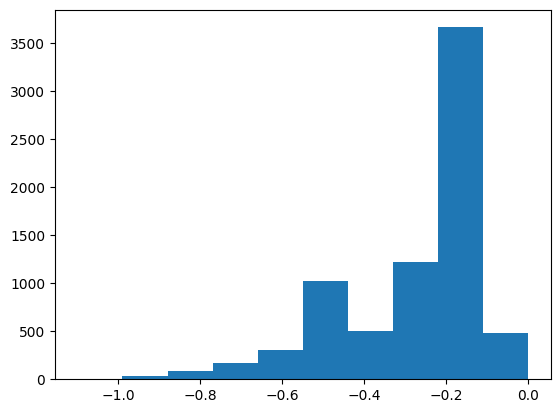

In [35]:
plt.hist(ground_truth_dict['0_43_M3_0.75']["lfc_truth"])

In [36]:
calculate_pearson_correlation(ground_truth_dict['0_43_M3_0.75'], performance_dict['0_43_M3_0.75'],"mellon_high_ls")

0.11573672082767923

In [37]:
compare_ranks_spearman(ground_truth_dict['0_43_M3_0.75'], performance_dict['0_43_M3_0.75'],"mellon_high_ls")

0.28701483853893045

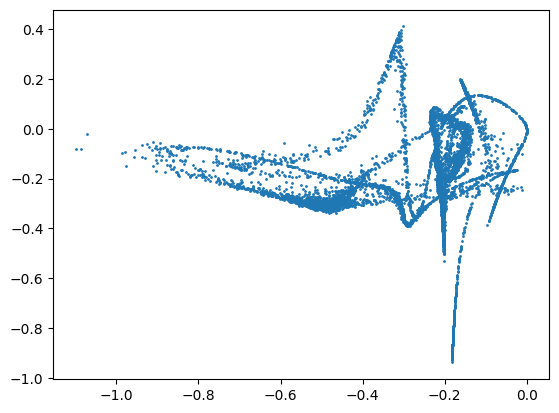

In [38]:
plt.scatter(ground_truth_dict['0_43_M3_0.75']["lfc_truth"], performance_dict['0_43_M3_0.75']["mellon_high_ls"], s=1)

In [39]:
calculate_pearson_correlation(ground_truth_dict['0_43_M3_0.75'], performance_dict['0_43_M3_0.75'],"meld_default")

0.7326143666305618

In [40]:
compare_ranks_spearman(ground_truth_dict['0_43_M3_0.75'], performance_dict['0_43_M3_0.75'],"meld_default")

0.6817339268006031

In [41]:
calculate_pearson_correlation(ground_truth_dict['0_43_M3_0.75'], performance_dict['0_43_M3_0.75'],"meld")

0.7597730616242953

In [42]:
compare_ranks_spearman(ground_truth_dict['0_43_M3_0.75'], performance_dict['0_43_M3_0.75'],"meld")

0.7009389167526918

In [43]:
modified_auroc(ground_truth_dict['0_43_M3_0.75'], performance_dict['0_43_M3_0.75'],"meld")

{'mean_auroc': 0.9529281886052718,
 'da_auroc': 0.7598393666101999,
 'neg_auroc': 0.9529281886052718,
 'pos_auroc': nan}

In [44]:
modified_auroc(ground_truth_dict['0_43_M3_0.75'], performance_dict['0_43_M3_0.75'],"meld_default")

{'mean_auroc': 0.9412714998652497,
 'da_auroc': 0.05872850013475014,
 'neg_auroc': 0.9412714998652497,
 'pos_auroc': nan}

In [45]:
modified_auroc(ground_truth_dict['0_43_M3_0.75'], performance_dict['0_43_M3_0.75'],"mellon_high_ls")

{'mean_auroc': 0.7082167303521469,
 'da_auroc': 0.6844035541952207,
 'neg_auroc': 0.7082167303521469,
 'pos_auroc': nan}

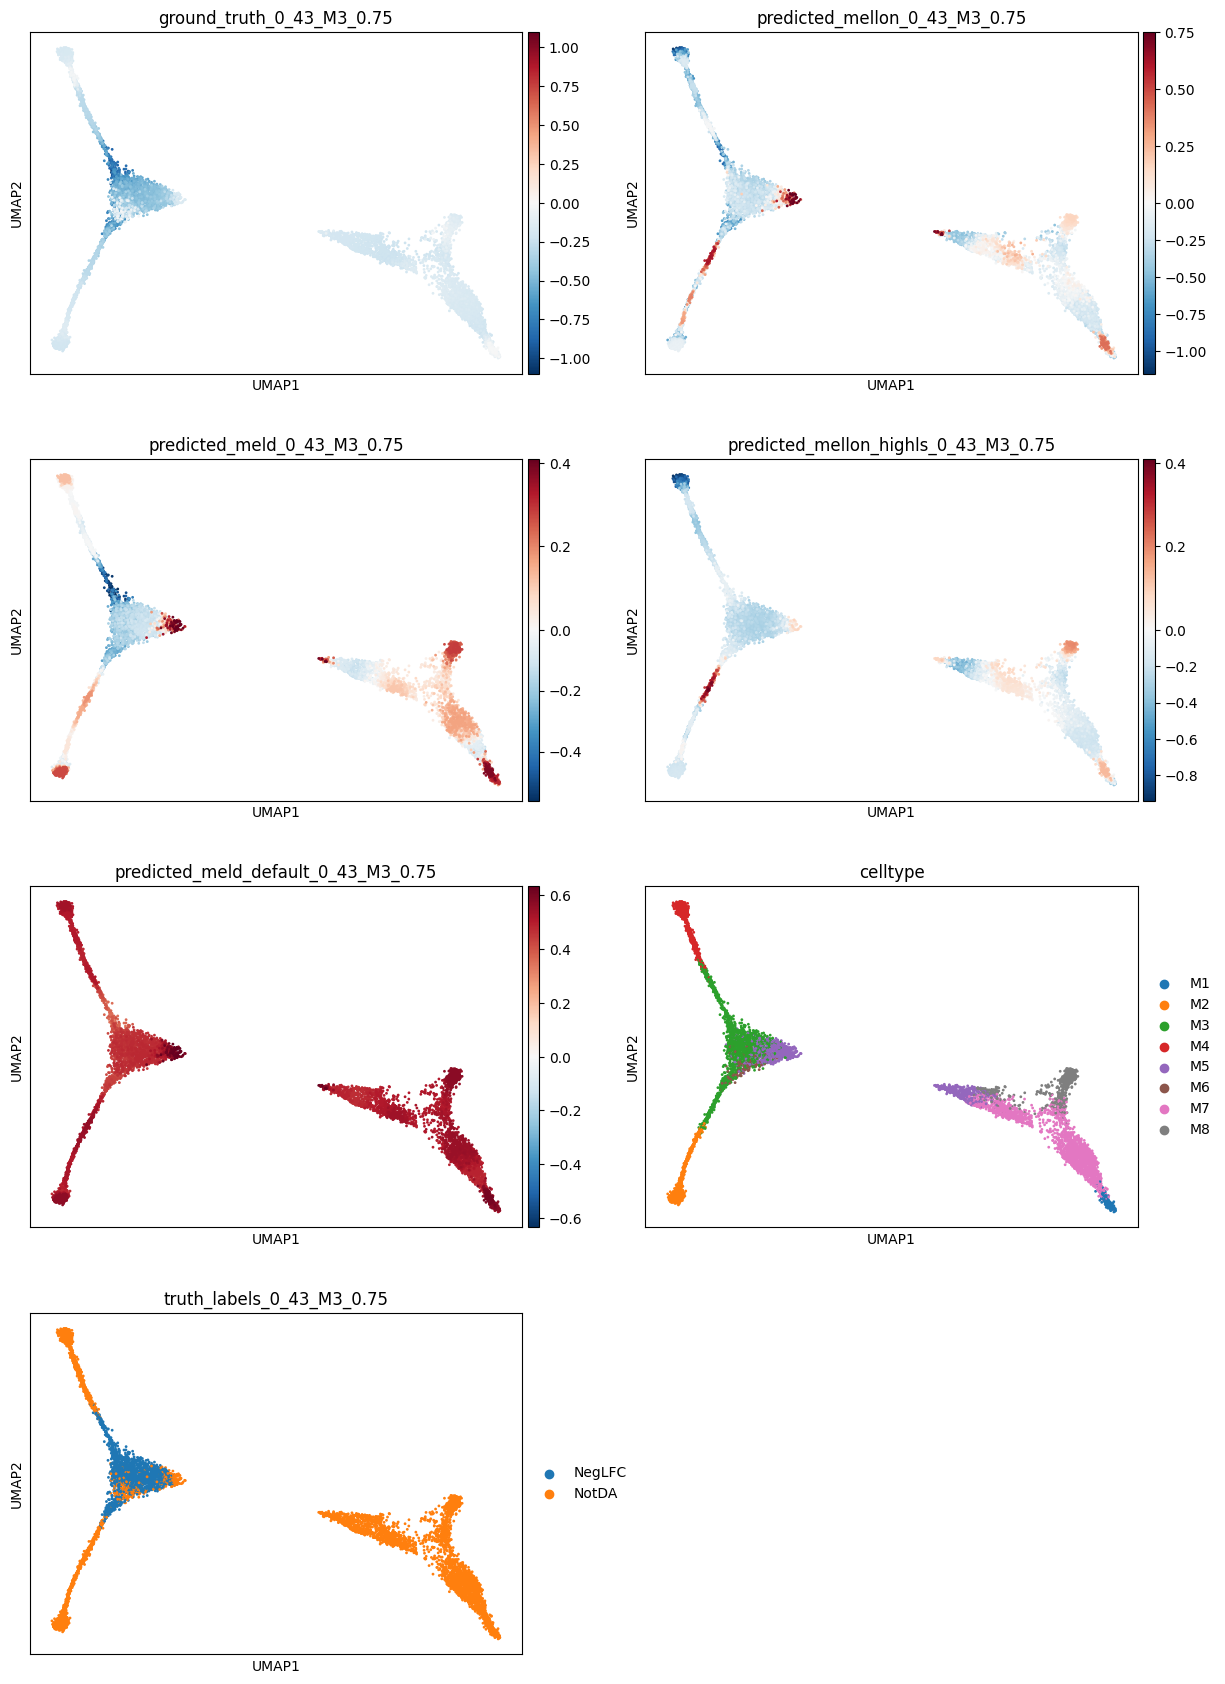

In [59]:
sc.pl.embedding(ad,"umap",color = ["ground_truth_0_43_M3_0.75","predicted_mellon_0_43_M3_0.75","predicted_meld_0_43_M3_0.75","predicted_mellon_highls_0_43_M3_0.75",
                                   "predicted_meld_default_0_43_M3_0.75","celltype","truth_labels_0_43_M3_0.75"], ncols = 2,cmap = "RdBu_r", vcenter=0)

In [53]:
ad.obs["ground_truth_0_43_M5_0.95"]= ground_truth_dict['0_43_M5_0.95']["lfc_truth"]
ad.obs["truth_labels_0_43_M5_0.95"]= ground_truth_dict['0_43_M5_0.95']["true_labels"]
ad.obs["predicted_mellon_0_43_M5_0.95"]= performance_dict['0_43_M5_0.95']["mellon"]
ad.obs["predicted_meld_0_43_M5_0.95"]= performance_dict['0_43_M5_0.95']["meld"]
ad.obs["predicted_mellon_highls_0_43_M5_0.95"]= performance_dict['0_43_M5_0.95']["mellon_high_ls"]
ad.obs["predicted_meld_default_0_43_M5_0.95"]= performance_dict['0_43_M5_0.95']["meld_default"]
ad.obs["predicted_louvain_0_43_M5_0.95"]= performance_dict['0_43_M5_0.95']["louvian"]
ad.obs["predicted_cydar_0_43_M5_0.95"]= performance_dict['0_43_M5_0.95']["cydar"]

KeyError: 'louvian'

In [48]:
print(calculate_pearson_correlation(ground_truth_dict['0_43_M5_0.95'], performance_dict['0_43_M5_0.95'],"mellon_high_ls"))
print(calculate_pearson_correlation(ground_truth_dict['0_43_M5_0.95'], performance_dict['0_43_M5_0.95'],"meld_default"))
print(calculate_pearson_correlation(ground_truth_dict['0_43_M5_0.95'], performance_dict['0_43_M5_0.95'],"meld"))

0.20779938723503247
0.8743889698847422
0.8942795993955859


In [49]:
print(compare_ranks_spearman(ground_truth_dict['0_43_M5_0.95'], performance_dict['0_43_M5_0.95'],"mellon_high_ls"))
print(compare_ranks_spearman(ground_truth_dict['0_43_M5_0.95'], performance_dict['0_43_M5_0.95'],"meld_default"))
print(compare_ranks_spearman(ground_truth_dict['0_43_M5_0.95'], performance_dict['0_43_M5_0.95'],"meld"))

0.38129307646032135
0.704747884898629
0.7433644255175897


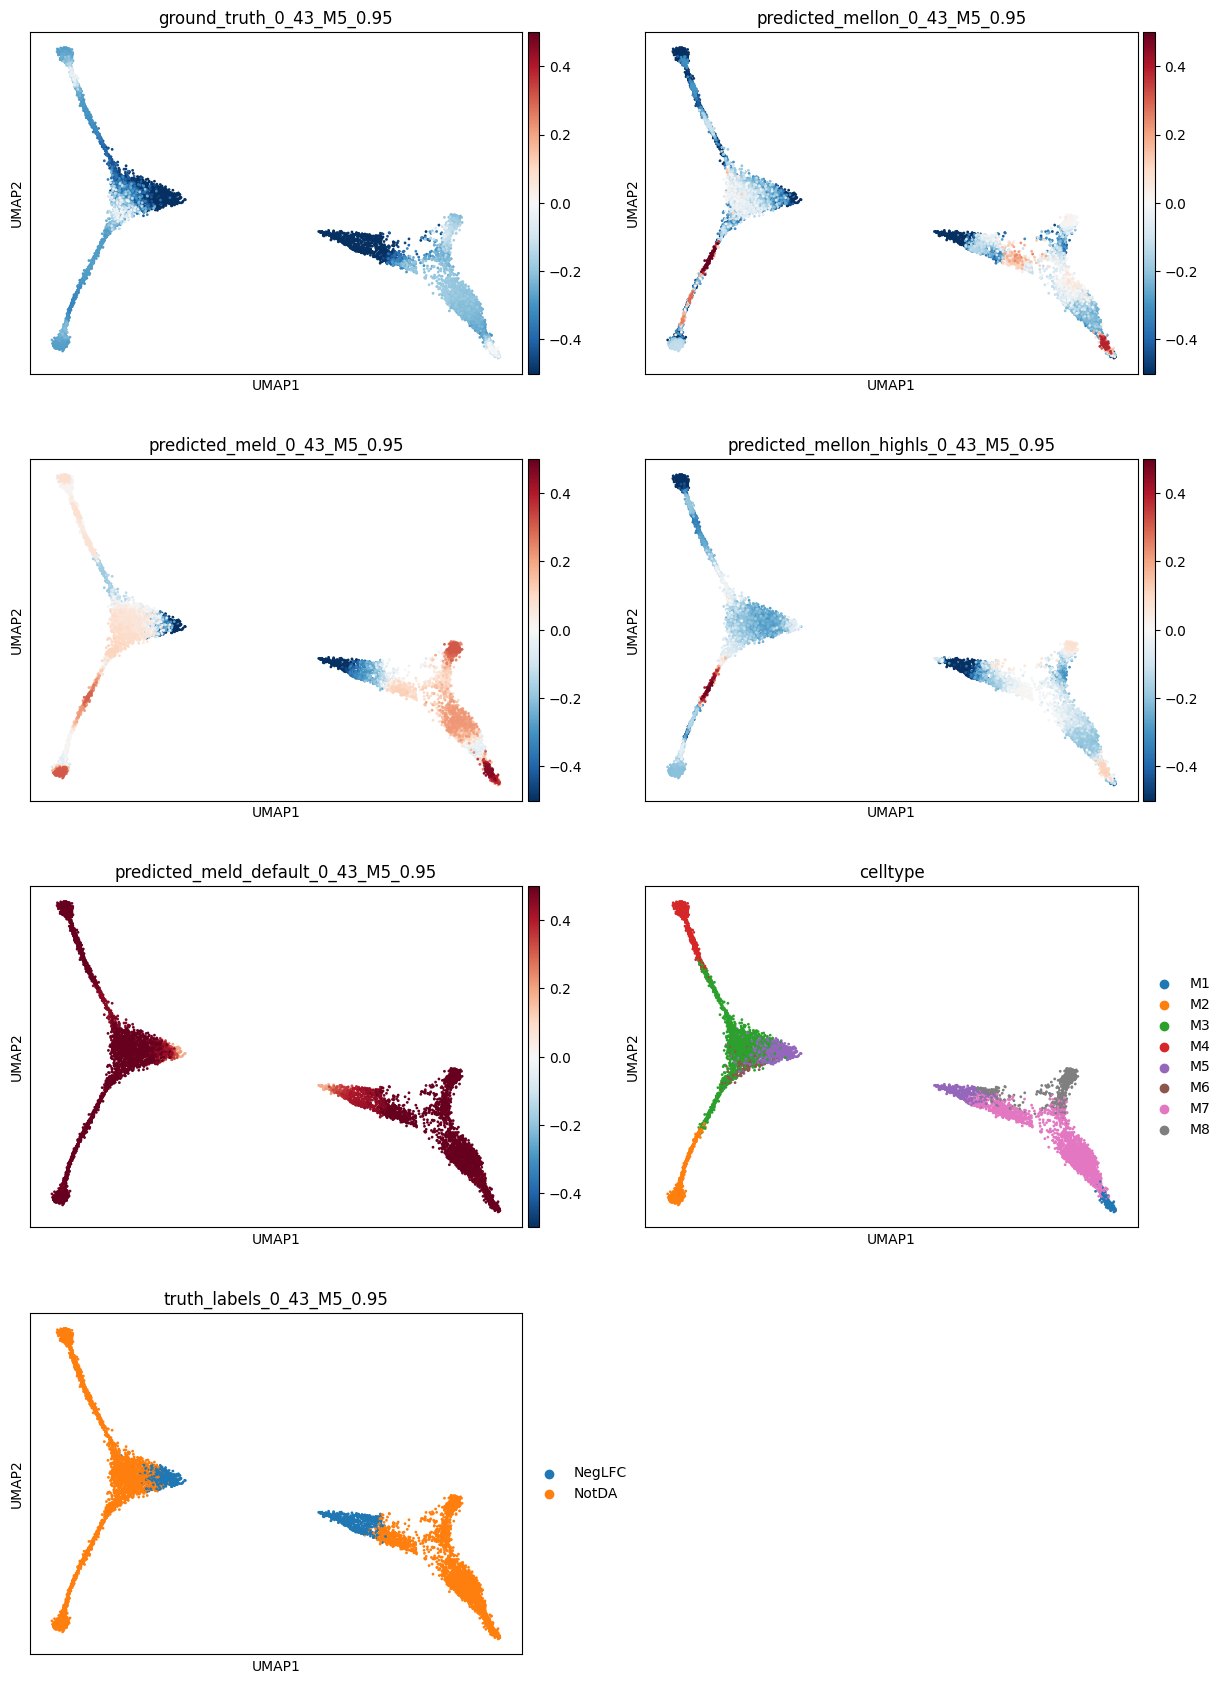

In [51]:
sc.pl.embedding(ad,"umap",color = ["ground_truth_0_43_M5_0.95","predicted_mellon_0_43_M5_0.95","predicted_meld_0_43_M5_0.95","predicted_mellon_highls_0_43_M5_0.95",
                                   "predicted_meld_default_0_43_M5_0.95","celltype","truth_labels_0_43_M5_0.95"], ncols = 2,cmap = "RdBu_r",vmax = 0.5,vmin = -0.5)

In [213]:
auroc_da_matrix = evaluation_details

In [214]:
auroc_da_matrix["meld_default"]

,0
0_43_M1_0.75_meld_default,0.111828
0_43_M2_0.75_meld_default,0.089138
0_43_M3_0.75_meld_default,0.058729
0_43_M4_0.75_meld_default,0.032160
0_43_M5_0.75_meld_default,0.018408
...,...
0_45_M4_0.95_meld_default,0.090240
0_45_M5_0.95_meld_default,0.012888
0_45_M6_0.95_meld_default,0.000069
0_45_M7_0.95_meld_default,0.031089


In [219]:
performance_dict,ground_truth_dict = get_results("branch")

In [223]:
performance_dict['0_43_M1_0.75']

,meld,mellon,daseq,milo,cydar,louvain,cna,meld_default,mellon_high_ls
C1,0.075681,-0.005956,0.179193,3.042547,8.077936e-28,0.174271,0.818417,0.524192,-0.056388
C2,-0.042923,0.149094,-0.098471,-0.766815,8.077936e-28,-0.026411,-0.090651,0.487277,0.084007
C3,-0.121988,-0.288967,-0.140082,-3.479564,8.077936e-28,-0.240097,-0.656905,0.465926,-0.261648
C4,0.084066,-0.006487,0.000209,-0.445608,8.077936e-28,0.174271,-0.200337,0.524425,-0.071331
C5,0.001040,-0.096581,-0.046914,0.000000,8.077936e-28,-0.001915,-0.352116,0.501189,-0.148944
...,...,...,...,...,...,...,...,...,...
C7496,-0.065091,0.097500,-0.076335,-0.581929,8.077936e-28,-0.026411,-0.660314,0.480379,0.035946
C7497,-0.149575,-0.233330,-0.112273,-1.317820,8.077936e-28,-0.212395,-0.181502,0.458536,0.072255
C7498,0.053360,0.286203,-0.054936,0.490534,8.077936e-28,-0.160111,0.037744,0.510657,0.051868
C7499,0.084559,-0.016149,-0.012822,0.641663,8.077936e-28,0.174271,-0.127533,0.524987,-0.059519


(array([ 185.,   58.,    9.,   13.,  397., 2010., 2431., 1899.,  429.,
          69.]),
 array([0.32158625, 0.34973911, 0.37789197, 0.40604483, 0.43419768,
        0.46235054, 0.4905034 , 0.51865626, 0.54680912, 0.57496198,
        0.60311484]),
 <BarContainer object of 10 artists>)

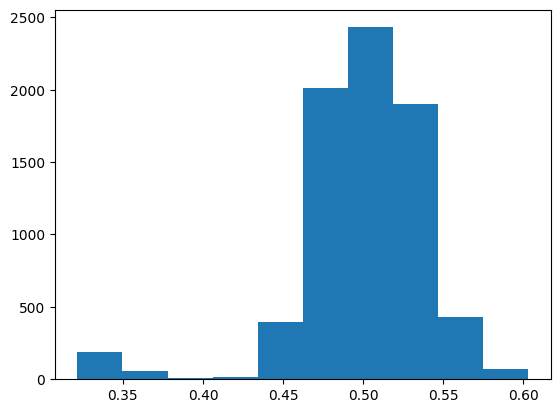

In [224]:
plt.hist(performance_dict['0_43_M1_0.75']["meld_default"])

(array([ 166.,   70.,   10.,   10.,   21.,  837., 2290., 2437., 1508.,
         151.]),
 array([-7.13785004e-01, -6.11837472e-01, -5.09889940e-01, -4.07942407e-01,
        -3.05994875e-01, -2.04047343e-01, -1.02099811e-01, -1.52278208e-04,
         1.01795254e-01,  2.03742786e-01,  3.05690319e-01]),
 <BarContainer object of 10 artists>)

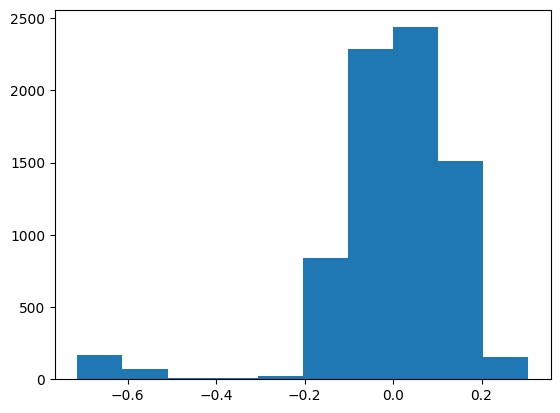

In [225]:
plt.hist(performance_dict['0_43_M1_0.75']["meld"])